# **Project 01**

## **Bài toán số 1 - Prediction with models**

**Import thư viện**

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn._core.typing import default
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
import joblib
import re, os, math, unicodedata, builtins
from scipy import stats
from scipy.special import inv_boxcox
from scipy.stats import skew

from functools import reduce
from itertools import combinations

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer, QuantileTransformer
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from bs4 import BeautifulSoup
from pyvi import ViTokenizer
from pyvi.ViTokenizer import tokenize
from gensim import models as gensim_models
from gensim import corpora, similarities
import gensim.similarities as gensim_similarities

from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer

import streamlit as st



**Load dữ liệu lưu vào biến data frame**

In [109]:
folder_path = 'Data'
csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]
data = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Loại bỏ trùng lặp
data = data.drop_duplicates()

**Xem thông tin chung dữ liệu**

In [110]:
# Print the shape of the dataset (rows, columns)
print("\nDataset shape:")
data.shape

# Display data types and non-null counts for each column
print("\nData types and missing values:")
data.info()

# Show summary statistics for each column (e.g., mean, std, min, max)
print("\nDescriptive statistics:")
data.describe(include='all')

# Check for missing values
print("\nMissing values per column:")
data.isnull().sum()


Dataset shape:

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
Index: 7941 entries, 0 to 8272
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tieu_de              7940 non-null   object 
 1   gia_ban              7939 non-null   object 
 2   don_gia              7939 non-null   object 
 3   dien_tich            7939 non-null   object 
 4   dia_chi              7941 non-null   object 
 5   mo_ta                7939 non-null   object 
 6   dien_thoai           3944 non-null   object 
 7   loai_hinh            7939 non-null   object 
 8   dien_tich_dat        7939 non-null   object 
 9   dien_tich_su_dung    3746 non-null   object 
 10  gia_m2               7939 non-null   object 
 11  giay_to_phap_ly      7440 non-null   object 
 12  so_phong_ngu         7939 non-null   object 
 13  so_phong_ve_sinh     5963 non-null   object 
 14  tong_so_tang         5488 non-null   float64


tieu_de                   1
gia_ban                   2
don_gia                   2
dien_tich                 2
dia_chi                   0
mo_ta                     2
dien_thoai             3997
loai_hinh                 2
dien_tich_dat             2
dien_tich_su_dung      4195
gia_m2                    2
giay_to_phap_ly         501
so_phong_ngu              2
so_phong_ve_sinh       1978
tong_so_tang           2453
tinh_trang_noi_that    3519
huong_cua_chinh        6623
dac_diem               2746
chieu_ngang            1851
chieu_dai              1987
ma_can                 7916
ten_phan_khu_lo        7916
bieu_do_gia               0
dtype: int64

**Xem thông tin mẫu**

In [111]:
print("First rows:")
data.head(1)


First rows:


,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,"3,85 tỷ","106,94 triệu/m²",36 m²,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,NaN,"Nhà ngõ, hẻm",36 m²,NaN,...,2 phòng,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5 m,8 m,NaN,NaN,"[134.04, 125.8, 125.8, 125.8, 138.64, 138.64, ..."


**Xử lý dữ liệu trùng --> đối với dữ liệu đã cho là các dòng không có dữ liệu trong quá trình crawl data**

In [112]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Số NaN': missing, 'Tỷ lệ (%)': missing_pct})
missing_df = missing_df[missing_df['Số NaN'] > 0].sort_values('Tỷ lệ (%)', ascending=False)
print('Các cột có giá trị thiếu:')
missing_df

Các cột có giá trị thiếu:


,Số NaN,Tỷ lệ (%)
ten_phan_khu_lo,7916,99.69
ma_can,7916,99.69
huong_cua_chinh,6623,83.40
dien_tich_su_dung,4195,52.83
dien_thoai,3997,50.33
tinh_trang_noi_that,3519,44.31
dac_diem,2746,34.58
tong_so_tang,2453,30.89
chieu_dai,1987,25.02
so_phong_ve_sinh,1978,24.91


In [113]:
print(f"Số dòng còn lại: {len(data)}")

Số dòng còn lại: 7941


**Tiền xử lý dữ liệu (Data Cleaning)**

**Xử lý đơn vị tiền tệ**

Thay các hàm udf và regexp_replace của Spark sang các hàm xử lý chuỗi của Pandas

In [114]:
def standardize_price(price_str):
    if pd.isna(price_str): return None
    price_str = str(price_str).lower().replace(',', '.')
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", price_str)
    if not nums: return None
    val = float(nums[0])
    if 'tỷ' in price_str: return val
    if 'triệu' in price_str: return val / 1000
    return val

# Áp dụng chuẩn hóa giá và diện tích
data['gia_ban'] = data['gia_ban'].apply(standardize_price)

cols_to_convert = ['dien_tich', 'dien_tich_dat', 'so_phong_ngu', 'chieu_ngang', 'tong_so_tang']
for col in cols_to_convert:
    data[col] = data[col].astype(str).str.replace('[^0-9,.]', '', regex=True).str.replace(',', '.')
    data[col] = pd.to_numeric(data[col], errors='coerce')


**Chuyển đổi các cột có đơn vị tính về dạng chỉ có số để tính toán**\
Riêng 2 cột 'don_gia', 'gia_m2' chỉ xử lý tượng trưng vì sẽ drop vì lý do ở những bước dưới

In [115]:
columns_to_convert = [
    'gia_ban', 'don_gia', 'dien_tich', 'dien_tich_dat', 'dien_tich_su_dung', 'gia_m2', 'so_phong_ngu',
    'so_phong_ve_sinh', 'chieu_ngang', 'chieu_dai'
]

for col_name in columns_to_convert:
    # Chuyển sang chuỗi, loại bỏ các ký tự không phải số, dấu phẩy, dấu chấm
    # Thay dấu phẩy thành dấu chấm
    # Chuyển sang kiểu số (float), các giá trị không hợp lệ sẽ tự động thành NaN (tương đương null)
    data[col_name] = (
        data[col_name]
        .astype(str)
        .str.replace(r'[^0-9,.]', '', regex=True)
        .str.replace(',', '.')
    )

    # Sử dụng pd.to_numeric với errors='coerce' để chuyển chuỗi rỗng hoặc lỗi thành NaN
    data[col_name] = pd.to_numeric(data[col_name], errors='coerce')

# Hiển thị 3 dòng đầu
data[columns_to_convert].head(3)

,gia_ban,don_gia,dien_tich,dien_tich_dat,dien_tich_su_dung,gia_m2,so_phong_ngu,so_phong_ve_sinh,chieu_ngang,chieu_dai
0,3.85,106.94,36.0,36.0,NaN,106.94,2.0,2.0,4.5,8.0
1,9.79,157.90,62.0,62.0,NaN,157.90,4.0,NaN,NaN,NaN
2,7.20,133.33,54.0,54.0,NaN,133.33,3.0,2.0,7.0,7.7


**Kiểm tra và điền các dòng giá trị không hợp lệ của chiều ngang về null**

In [116]:
def clean_invalid_dimensions_pandas(df):
    # Tạo biến tạm để tính toán
    df['dien_tich_tmp'] = np.where(
        df['chieu_ngang'].notna() & df['chieu_dai'].notna(), # Điều kiện (When)
        df['chieu_ngang'] * df['chieu_dai'],                 # Kết quả nếu True
        0                                                    # Kết quả nếu False
    )

    # Điều kiện 1: chieu_ngang > dien_tich
    cond1 = df['chieu_ngang'] > df['dien_tich']

    # Điều kiện 2: sai lệch diện tích > 0 (chỉ kiểm tra khi cả 3 cột not null)
    cond2 = (df['chieu_ngang'].notna()) & \
            (df['chieu_dai'].notna()) & \
            (df['dien_tich'].notna()) & \
            (abs(df['dien_tich'] - df['dien_tich_tmp']) > 0)

    # Nếu vi phạm bất kỳ điều kiện nào (cond1 HOẶC cond2) -> Gán NaN
    df['chieu_ngang'] = np.where(cond1 | cond2, np.nan, df['chieu_ngang'])

    # Loại bỏ cột tạm dien_tich_tmp để làm sạch DataFrame kết quả
    df = df.drop(columns=['dien_tich_tmp'])
    return df

# Sử dụng:
data = clean_invalid_dimensions_pandas(data)

In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7941 entries, 0 to 8272
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tieu_de              7940 non-null   object 
 1   gia_ban              7939 non-null   float64
 2   don_gia              7939 non-null   float64
 3   dien_tich            7939 non-null   float64
 4   dia_chi              7941 non-null   object 
 5   mo_ta                7939 non-null   object 
 6   dien_thoai           3944 non-null   object 
 7   loai_hinh            7939 non-null   object 
 8   dien_tich_dat        7939 non-null   float64
 9   dien_tich_su_dung    3746 non-null   float64
 10  gia_m2               7939 non-null   float64
 11  giay_to_phap_ly      7440 non-null   object 
 12  so_phong_ngu         7939 non-null   float64
 13  so_phong_ve_sinh     5963 non-null   float64
 14  tong_so_tang         5488 non-null   float64
 15  tinh_trang_noi_that  4422 non-null   object

**Kiểm tra biến numerical mang giá trị 0 hoặc nhỏ hơn 0 là các giá trị invalid**

In [118]:
# Lọc các cột có kiểu dữ liệu là số (tương đương double, integer trong Spark)
numeric_df = data.select_dtypes(include=['number'])

# Đếm các giá trị bằng 0 trong các cột này
zero_and_negative_count = (numeric_df <= 0).sum()

# Hiển thị kết quả
zero_and_negative_count.to_frame(name='zero_and_negative_count').T

,gia_ban,don_gia,dien_tich,dien_tich_dat,dien_tich_su_dung,gia_m2,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,chieu_ngang,chieu_dai
zero_and_negative_count,0,0,0,0,0,0,0,0,0,0,0


**Kiểm tra null**

In [119]:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

print("Số lượng giá trị Null trong các cột số:")
data[numeric_cols].isnull().sum()

Số lượng giá trị Null trong các cột số:


gia_ban                 2
don_gia                 2
dien_tich               2
dien_tich_dat           2
dien_tich_su_dung    4195
gia_m2                  2
so_phong_ngu            2
so_phong_ve_sinh     1978
tong_so_tang         2453
chieu_ngang          5573
chieu_dai            1987
dtype: int64

**Vẽ biểu đồ tương quan để xét tính đa cộng tuyến**\
Nhận xét:
- 'chieu_dai' có tương quan mạnh với 'dien_tich_dat' (0.76) -> cần drop cột 'chieu_dai' để tránh đa cộng tuyến
- Tương tự cần drop cột 'so_phong_ve_sinh', giữ lại 'so_phong_ngu', vì 'so_phong_ngu' không có Null

In [120]:
def visualize_correlation(df):
    #
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    corr_df = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Numeric Features')
    plt.show()

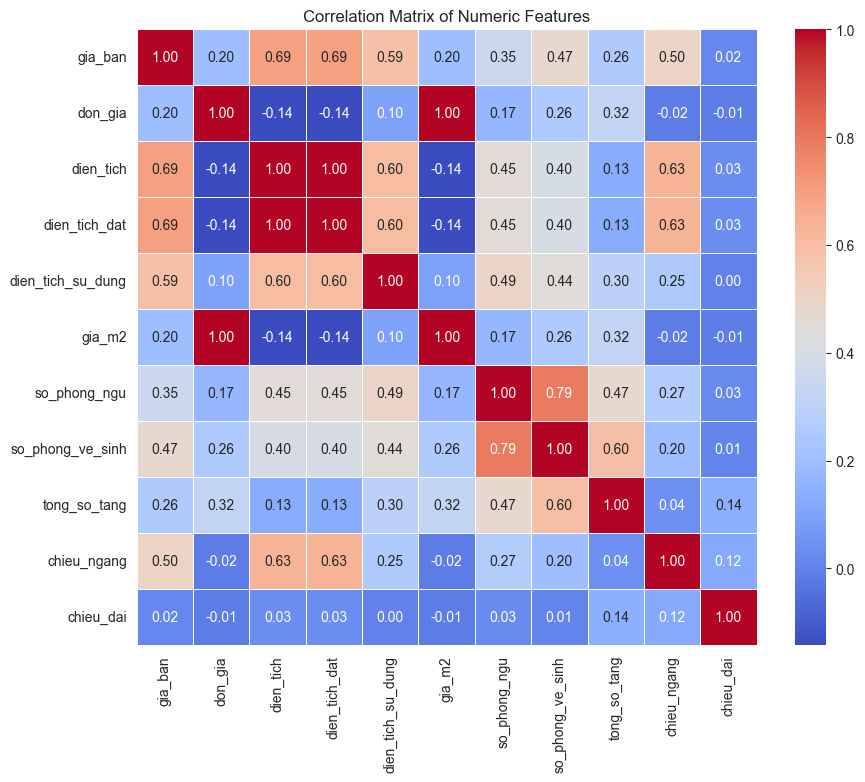

In [121]:
visualize_correlation(data)

**Drop các cột không có ý nghĩa thống kê và có sự tương quan, một số cột khác sẽ được drop sau khi trích xuất thông tin, vd: 'tieu_de', 'mo_ta', 'dia_chi', 'chieu_dai'**
- Đơn giá = giá bán/ diện tích đất
- Diện tích = diện tích đất
- Chiều dài: tương quan với Diện tích đất
- Số phòng vệ sinh tương quan với Số phòng ngủ
- Giá m2 = đơn giá
- Điện thoại, mã căn, tên phân khu/lô, biểu đồ giá: không có ý nghĩa thống kê

In [122]:
# Danh sách các cột cần loại bỏ
cols_to_drop = ['don_gia', 'dien_tich', 'so_phong_ve_sinh', 'gia_m2', 'dien_thoai', 'ma_can', 'ten_phan_khu_lo', 'bieu_do_gia']

# Sử dụng drop với axis=1 để xóa cột
# errors='ignore' giúp code không bị lỗi nếu một trong các cột đã bị xóa trước đó
data = data.drop(columns=cols_to_drop, errors='ignore')

# Hiển thị 3 dòng đầu (tương đương .show(3))
data.head(3)

,tieu_de,gia_ban,dia_chi,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,3.85,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,"Nhà ngõ, hẻm",36.0,NaN,Đã có sổ,2.0,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5,8.0
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...",9.79,"Đường Phạm Văn Đồng, Phường 13, Quận Bình Thạn...","CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...","Nhà ngõ, hẻm",62.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,7.20,"Đường Nơ Trang Long, Phường 13, Quận Bình Thạn...",XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,"Nhà ngõ, hẻm",54.0,NaN,Đã có sổ,3.0,2.0,Hoàn thiện cơ bản,NaN,Hẻm xe hơi,NaN,7.7


**Thêm feature là 2 cột địa chỉ cũ, địa chỉ mới từ cột địa chỉ, vì địa chỉ phản ánh khu vực mặt bằng giá nên có liên quan đến giá nhà, vd nhà quận 1 thường đắt hơn nhà các quận khác, sau đó drop cột địa chi vì không còn nhu cầu phân tích thống kê**

In [123]:
# Trích xuất dia_chi_cu
# Regex: (Phường\s+[^,]+,\s+Quận\s+[^,]+)
data['dia_chi_cu'] = data['dia_chi'].str.extract(r'(Phường\s+[^,]+,\s+Quận\s+[^,]+)', expand=False)

# Trích xuất dia_chi_moi
# Regex: \((Phường\s+[^,]+)
data['dia_chi_moi'] = data['dia_chi'].str.extract(r'\((Phường\s+[^,]+)', expand=False)

# Xử lý các trường hợp không tìm thấy (NaN hoặc chuỗi rỗng)
# Trong Pandas, nếu không khớp Regex, kết quả trả về là NaN (tương đương null)
dia_chi_cols = ['dia_chi_cu', 'dia_chi_moi']
for col_name in dia_chi_cols:
    # Thay thế cả NaN và chuỗi rỗng bằng 'Chưa xác định'
    data[col_name] = data[col_name].replace(['', np.nan], 'Chưa xác định')

# Loại bỏ cột gốc và hiển thị kết quả
data = data.drop(columns=['dia_chi'])

data[['dia_chi_cu', 'dia_chi_moi']].head(3)

,dia_chi_cu,dia_chi_moi
0,"Phường 7, Quận Bình Thạnh",Phường Gia Định
1,"Phường 13, Quận Bình Thạnh",Phường Bình Lợi Trung
2,"Phường 13, Quận Bình Thạnh",Phường Bình Lợi Trung


**Xử lý Null**

**Chúng ta sẽ xử lý theo thứ tự lần lượt như sau:**
- 'loai_hinh', 'dien_tich_dat', 'so_phong_ngu': xử lý null bằng cách xóa 2 dòng dữ liệu invalid
- 'tong_so_tang': được trích xuất thông tin từ 2 cột 'tieu_de' và 'mo_ta'
- 'dien_tich_su_dung' có mối tương quan với 'dien_tich_dat' và 'tong_so_tang', nên dùng model Linear Regression để dự đoán
- 'chieu_ngang' được xử lý lần lượt qua 2 phương án:\
\+ PA1: Tính dựa vào 'dien_tich_dat' và 'chieu_dai' sẵn có: chieu_ngang = dien_tich_dat/chieu_dai\
\+ PA2: Tính dựa vào median / mean tỷ lệ thực tế trong dữ liệu
→ Tính ratio = chieu_ngang / chieu_dai (hoặc ngược lại) từ các hàng có cả 2 cột không null → lấy median(ratio) → chieu_ngang ≈ sqrt(dien_tich_dat / median_ratio)
- 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem': tỉ lệ null thấp --> xử lý null bằng cách điền giá trị 'Chưa xác định', 'Hiện trạng khác'
- 'huong_cua_chinh': tỉ lệ null cao, nhưng do yếu tố ngẫu nhiên của hướng --> dùng phương pháp random

**Kiểm tra và xử lý 2 dòng dữ liệu invalid, 2 dòng này làm tăng số dòng null của tất cả các cột**

In [124]:
# Lọc các dòng có 'dien_tich_dat' là Null
null_data = data[data['dien_tich_dat'].isna()]

# In kết quả dạng bảng
if null_data.empty:
    print("Không có dòng nào bị Null trong cột dien_tich_dat.")
else:
    print(f"Tìm thấy {len(null_data)} dòng bị Null:")
    display(null_data.head(10))

Tìm thấy 2 dòng bị Null:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,dia_chi_cu,dia_chi_moi
1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chưa xác định,Chưa xác định
1814,Bad gateway Error code 502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chưa xác định,Chưa xác định


In [125]:
# Xóa null các dòng invalid
data = data.dropna(subset=['dien_tich_dat'])
null_counts_df = data.isnull().sum().to_frame(name='null_counts').T
print("Bảng thống kê số lượng Null sau khi xóa dòng invalid:")
display(null_counts_df)

Bảng thống kê số lượng Null sau khi xóa dòng invalid:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,dia_chi_cu,dia_chi_moi
null_counts,0,0,0,0,0,4193,499,0,2451,3517,6621,2744,5571,1985,0,0


**Xử lý null cho cột 'tong_so_tang', phương án như sau:**
- Dùng regex để nhận diện số lầu, lửng hoặc tầng
- Ưu tiên nếu có thông tin số tầng thì lấy số tầng trực tiếp từ text
- Tìm thông tin lầu, lửng để suy ra số tầng = lầu + lửng + 1
- Nếu không có thông tin lầu, lửng hoặc số tầng thì mặc định số tầng = 1

In [126]:
def extract_floor_count(text):
    if not text or not isinstance(text, str):
        return None

    text_lower = text.lower()

    lau_variants = ['lầu', 'lẩu', 'làu', 'lâù', 'lâu']
    lung_variants = ['lửng', 'lững', 'lừng', 'lữn', 'lưng', 'lủng']

    lau_pattern = '|'.join(lau_variants)
    lung_pattern = '|'.join(lung_variants)

    tang_pattern = r'(\d+)\s*tầng'
    tang_matches = re.findall(tang_pattern, text_lower)

    if tang_matches:
        return int(tang_matches[0])

    floor_pattern = fr'(\d+)\s*({lau_pattern})'
    mezz_pattern = fr'(\d+)\s*({lung_pattern})'

    floor_matches = re.findall(floor_pattern, text_lower)
    mezz_matches = re.findall(mezz_pattern, text_lower)

    floor_numbers = set([match[0] for match in floor_matches])
    mezz_numbers = set([match[0] for match in mezz_matches])

    has_lau = any(variant in text_lower for variant in lau_variants)
    has_lung = any(variant in text_lower for variant in lung_variants)

    if floor_numbers or mezz_numbers or has_lau or has_lung:
        total_floors = 1
        for f in floor_numbers:
            total_floors += int(f)
        for m in mezz_numbers:
            total_floors += int(m)

        if has_lau and not floor_numbers:
            total_floors += 1
        if has_lung and not mezz_numbers:
            total_floors += 1

        return total_floors
    return None

# Tạo 2 cột mới
data['mo_ta_so_tang'] = data['mo_ta'].apply(extract_floor_count)
data['tieu_de_so_tang'] = data['tieu_de'].apply(extract_floor_count)

# Imputing

# Case 1: Nếu tong_so_tang, tieu_de_so_tang, mo_ta_so_tang đều null -> gán bằng 1
# Sử dụng .isna() và .loc để gán giá trị có điều kiện
mask_all_null = data['tong_so_tang'].isna() & \
                data['tieu_de_so_tang'].isna() & \
                data['mo_ta_so_tang'].isna()
data.loc[mask_all_null, 'tong_so_tang'] = 1

# Case 2: Nếu tong_so_tang bị null, lấy giá trị từ mo_ta hoặc tieu_de (Coalesce)
data['tong_so_tang'] = data['tong_so_tang'].fillna(data['mo_ta_so_tang'])
data['tong_so_tang'] = data['tong_so_tang'].fillna(data['tieu_de_so_tang'])

# Hiển thị kết quả
cols_to_show = ["tieu_de", "tieu_de_so_tang", "mo_ta", "mo_ta_so_tang", "tong_so_tang"]
data[cols_to_show].head(10)

,tieu_de,tieu_de_so_tang,mo_ta,mo_ta_so_tang,tong_so_tang
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,NaN,🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,2.0,2.0
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...",NaN,"CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...",4.0,4.0
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,NaN,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,2.0,2.0
3,🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN XÂY M...,NaN,#e45\n🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN...,NaN,1.0
4,Nhà hẻm cách đường mặt tiền 20m,NaN,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,NaN,1.0
5,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,2.0,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",NaN,2.0
6,Bán nhà 50m,NaN,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",3.0,3.0
7,❌ GIẢM GẤP 200TR ❌ Nhà đẹp sát City Garden Bìn...,NaN,🚨 GIÁ *** KHU 🚨\nNhà đẹp P21 Bình Thạnh – 2 tầ...,2.0,2.0
8,"NHÀ 5LẦU MẶT TIỀN ĐƯỜNG NGUYỄN VĂN THƯƠNG,P25,...",6.0,"$-) 25,8ty TL - BÁN TÒA NHÀ VP, MẶT TIỀN SỐ 89...",5.0,5.0
9,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,NaN,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,4.0,4.0


**Kiểm tra và clean data đối với 'tong_so_tang' lớn hơn 8, vì nhà phố quy định thường không quá 8 (Theo Quyết định 135/2007/QĐ-UBND về kiến trúc nhà liên kế trong khu đô thị hiện hữu của TPHCM)**

In [127]:
count_high_floors = data[data['tong_so_tang'] > 8].shape[0]
print(f"Số lượng căn nhà có trên 8 tầng: {count_high_floors}")

Số lượng căn nhà có trên 8 tầng: 15


In [128]:
data = data[data['tong_so_tang'] <= 8]
print(f"Số dòng còn lại: {len(data)}")

Số dòng còn lại: 7924


**Xử lý null cho cột 'dien_tich_su_dung'**

In [129]:
# Xác định điều kiện cho training_data và predict_data
training_condition = (
    data['dien_tich_su_dung'].notna() &
    data['dien_tich_dat'].notna() &
    data['tong_so_tang'].notna()
)

predict_condition = (
    data['dien_tich_su_dung'].isna() &
    data['dien_tich_dat'].notna() &
    data['tong_so_tang'].notna()
)

# Tạo tập Train và tập Predict
training_data = data[training_condition].copy()
predict_data = data[predict_condition].copy()

print(f"Total rows: {len(data)}")
print(f"Rows in training_data: {len(training_data)}")
print(f"Rows in predict_data: {len(predict_data)}")

# Chuẩn bị Feature (X) và Target (y)
feature_cols = ["dien_tich_dat", "tong_so_tang"]
X_train = training_data[feature_cols]
y_train = training_data["dien_tich_su_dung"]
X_predict = predict_data[feature_cols]

# Khởi tạo và huấn luyện model Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Dự đoán giá trị còn thiếu
if not predict_data.empty:
    y_pred = lr.predict(X_predict)

    # Chặn các giá trị âm (Capping): nếu < 0 thì lấy giá trị của dien_tich_dat
    # Tương đương logic: when(col("prediction") < 0, col("dien_tich_dat"))
    y_pred_capped = np.where(y_pred < 0, predict_data['dien_tich_dat'], y_pred)

    # Gán giá trị dự đoán vào cột dien_tich_su_dung của predict_data
    predict_data['dien_tich_su_dung'] = y_pred_capped

# Gộp dữ liệu lại (Union)
# Những dòng không thỏa mãn cả 2 điều kiện trên (nếu có) cũng cần được giữ lại
other_data = data[~(training_condition | predict_condition)]

data_imputed = pd.concat([training_data, predict_data, other_data], axis=0).reset_index(drop=True)

# Kiểm tra lại số lượng Null
print("\nSố lượng Null còn lại trong cột 'dien_tich_su_dung':")
print(data_imputed['dien_tich_su_dung'].isna().sum())

# Hiển thị mẫu kết quả
print("\nMẫu dữ liệu sau khi điền khuyết:")
display(predict_data[feature_cols + ['dien_tich_su_dung']].head(10))

# Cập nhật lại biến data chính
data = data_imputed

Total rows: 7924
Rows in training_data: 3737
Rows in predict_data: 4187

Số lượng Null còn lại trong cột 'dien_tich_su_dung':
0

Mẫu dữ liệu sau khi điền khuyết:


,dien_tich_dat,tong_so_tang,dien_tich_su_dung
0,36.0,2.0,50.498670
1,62.0,4.0,189.137132
2,54.0,2.0,90.563910
3,83.0,1.0,114.730241
7,26.0,2.0,28.240203
10,60.0,4.0,184.685439
14,48.0,2.0,77.208830
15,70.0,3.0,166.560682
21,40.0,4.0,140.168505
22,72.0,2.0,130.629151


**Xử lý null cho cột 'chieu_ngang' --> PA1**

In [130]:
# Tính toán lại chieu_ngang dựa trên dien_tich_dat và chieu_dai
# Điều kiện: diện tích đất và chiều dài có giá trị, nhưng chiều ngang bị thiếu (Null)
mask = (data['dien_tich_dat'].notna()) & \
       (data['chieu_ngang'].isna()) & \
       (data['chieu_dai'].notna()) & \
       (data['chieu_dai'] > 0) & \
       (data['dien_tich_dat'] > 0)

# Áp dụng công thức: chiều ngang = diện tích / chiều dài
data.loc[mask, 'chieu_ngang'] = data['dien_tich_dat'] / data['chieu_dai']

# Đếm số lượng Null ở tất cả các cột và hiển thị dạng bảng (tương đương .show())
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi tính toán chiều ngang:")
display(null_summary)

Bảng thống kê số lượng Null sau khi tính toán chiều ngang:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,dia_chi_cu,dia_chi_moi,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,498,0,0,3512,6609,2742,1840,1982,0,0,1030,4302


**Xử lý null cho cột 'chieu_ngang' --> PA2**

In [131]:
# --- Bước 1: Tính tỷ lệ ngang / dài trung vị (Median Ratio) ---
# Lọc các hàng có đủ ngang và dài (>0) để tính tỷ lệ mẫu
valid_mask = (data['chieu_ngang'].notna()) & (data['chieu_dai'] > 0)
ratio_ngang_dai = data.loc[valid_mask, 'chieu_ngang'] / data.loc[valid_mask, 'chieu_dai']

# Tính median (tương đương percentile_approx 0.5)
median_ratio = ratio_ngang_dai.median()

# Fallback nếu không tính được median
if pd.isna(median_ratio) or median_ratio <= 0:
    median_ratio = 0.3

print(f"Median Ratio (Ngang/Dài) tính được: {median_ratio:.4f}")

# --- Bước 2: Impute cho các hàng thiếu cả ngang + dài nhưng có dien_tich_dat ---
# Điều kiện: Cả ngang và dài đều Null, nhưng diện tích đất thì có
impute_mask = (data['chieu_ngang'].isna()) & \
              (data['chieu_dai'].isna()) & \
              (data['dien_tich_dat'].notna())

# Tính toán giá trị tạm thời
# Công thức: diện tích = ngang * dài => diện tích = (dài * ratio) * dài => dài = sqrt(diện tích / ratio)
# Ngược lại: ngang = sqrt(diện tích * ratio)
temp_ngang = np.sqrt(data.loc[impute_mask, 'dien_tich_dat'] * median_ratio)
temp_dai = data.loc[impute_mask, 'dien_tich_dat'] / temp_ngang

# Cập nhật vào dataframe gốc (tương đương coalesce)
data.loc[impute_mask, 'chieu_ngang'] = temp_ngang
data.loc[impute_mask, 'chieu_dai'] = temp_dai

# --- Bước 3: Kiểm tra lại kết quả ---
null_summary = data.isnull().sum().to_frame(name='null_count').T
print("\nSố lượng Null sau khi xử lý ngang/dài đồng thời:")
display(null_summary)

Median Ratio (Ngang/Dài) tính được: 0.3400

Số lượng Null sau khi xử lý ngang/dài đồng thời:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,dia_chi_cu,dia_chi_moi,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,498,0,0,3512,6609,2742,0,142,0,0,1030,4302


**Xử lý null cho các cột 'giay_to_phap_ly', 'tinh_trang_noi_that', 'dac_diem'**

In [132]:
# Điền giá trị khuyết cho các cột phân loại bằng dictionary
fill_values = {
    'giay_to_phap_ly': 'Chưa xác định',
    'tinh_trang_noi_that': 'Chưa xác định',
    'dac_diem': 'Hiện trạng khác'
}

data = data.fillna(value=fill_values)

# Kiểm tra lại số lượng Null của tất cả các cột dạng bảng (tương đương .show())
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi fillna:")
display(null_summary)

Bảng thống kê số lượng Null sau khi fillna:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,dia_chi_cu,dia_chi_moi,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,0,0,0,0,6609,0,0,142,0,0,1030,4302


**Xử lý null cho cột 'huong_cua_chinh'**

In [133]:
def impute_with_distribution_pandas(df, col='huong_cua_chinh', random_state=42):
    """
    Điền null bằng random sample theo distribution thực tế sử dụng Pandas & Numpy.
    """
    # Tính toán phân phối xác suất (tương đương value_counts + prob trong Spark)
    # normalize=True sẽ tự động chia cho tổng số lượng non-null
    dist = df[col].value_counts(normalize=True)

    values = dist.index.tolist()
    probs = dist.values.tolist()

    # Xác định các vị trí bị Null
    is_null = df[col].isna()
    null_count = is_null.sum()

    if null_count > 0:
        # Tạo mẫu ngẫu nhiên dựa trên phân phối đã tính
        rng = np.random.default_rng(random_state)
        random_values = rng.choice(values, size=null_count, p=probs)

        # Điền các giá trị ngẫu nhiên vào đúng các vị trí Null
        df.loc[is_null, col] = random_values

    return df

# Thực hiện điền khuyết
data = impute_with_distribution_pandas(data)

# Kiểm tra lại số lượng Null của tất cả các cột
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:")
display(null_summary)

Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:


,tieu_de,gia_ban,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,dia_chi_cu,dia_chi_moi,mo_ta_so_tang,tieu_de_so_tang
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0,142,0,0,1030,4302


**Xử lý khoảng trắng cho giá trị trong các cột category để tránh lỗi khi chạy thuật toán**

In [134]:
def sanitize_string(s):
    if s is None or pd.isna(s): # Kiểm tra thêm pd.isna cho chắc chắn trong Pandas
        return None

    s = str(s).lower()

    # Loại bỏ dấu tiếng Việt
    s = unicodedata.normalize('NFKD', s)
    s = "".join([c for c in s if not unicodedata.combining(c)])
    s = s.replace('đ', 'd').replace('Đ', 'D')

    # Thay thế ký tự đặc biệt và khoảng trắng
    s = re.sub(r'[^\w\s]', '_', s)
    s = re.sub(r'[\s,:\\[\]{}]+', '_', s)

    # Dọn dẹp dấu gạch dưới thừa
    s = re.sub(r'_+', '_', s)
    s = s.strip('_')

    return s

# Danh sách các cột phân loại
categorical_cols = [
    'loai_hinh', 'giay_to_phap_ly', 'tinh_trang_noi_that',
    'huong_cua_chinh', 'dac_diem', 'dia_chi_cu', 'dia_chi_moi'
]

# Áp dụng cho các cột trong danh sách bằng .apply()
# Pandas cho phép lọc các cột tồn tại rất dễ dàng
existing_cols = [c for c in categorical_cols if c in data.columns]

for col_name in existing_cols:
    data[col_name] = data[col_name].apply(sanitize_string)

# Hiển thị mẫu dữ liệu sau khi làm sạch
print("Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:")
display(data[existing_cols].head(5))

Mẫu dữ liệu sau khi lower case, bỏ dấu và ký tự đặc biệt:


,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi
0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac,phuong_12_quan_binh_thanh,phuong_binh_thanh
1,nha_ngo_hem,da_co_so,chua_xac_dinh,dong_bac,hien_trang_khac,phuong_15_quan_binh_thanh,phuong_gia_dinh
2,nha_ngo_hem,da_co_so,chua_xac_dinh,dong,hem_xe_hoi,phuong_26_quan_binh_thanh,phuong_binh_thanh
3,nha_mat_pho_mat_tien,da_co_so,noi_that_day_du,dong,hien_trang_khac,phuong_25_quan_binh_thanh,phuong_thanh_my_tay
4,nha_ngo_hem,da_co_so,chua_xac_dinh,nam,hem_xe_hoi,phuong_24_quan_binh_thanh,phuong_binh_thanh


**Copy data cho project 1**

In [135]:
# Danh sách các cột cần giữ lại
selected_columns = ['tieu_de', 'mo_ta', 'dien_tich_dat', 'dien_tich_su_dung', 'chieu_ngang', \
                    'tong_so_tang', 'so_phong_ngu', 'loai_hinh', 'giay_to_phap_ly', \
                    'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem', 'dia_chi_cu', 'dia_chi_moi', 'gia_ban']

data = data[selected_columns].copy()

**Kiểm tra lại dữ liệu**

In [141]:
# Hiển thị cấu trúc dữ liệu và 5 dòng đầu tiên để kiểm tra
print(f"Kích thước dữ liệu sau khi chọn lọc: {data.shape}")
data.head(5)

Kích thước dữ liệu sau khi chọn lọc: (7924, 15)


,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban
0,Nhà hẻm cách đường mặt tiền 20m,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,18.0,18.0,3.000000,1.0,2.0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac,phuong_12_quan_binh_thanh,phuong_binh_thanh,2.85
1,BÁN NHÀ 2 TẦNG HẺM BẠCH ĐẰNG,"Nhà hẻm Bạch Đằng \nDân cư an ninh, yên tĩnh\n...",120.0,166.0,5.714286,2.0,5.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong_bac,hien_trang_khac,phuong_15_quan_binh_thanh,phuong_gia_dinh,13.00
2,Bán nhà 50m,"👉Nhà 3 TẦNG -HẺM XE HƠI - gía:11,2 TỶ \n👉Có gi...",59.4,59.4,5.256637,3.0,4.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong,hem_xe_hoi,phuong_26_quan_binh_thanh,phuong_binh_thanh,11.20
3,"NHÀ 5LẦU MẶT TIỀN ĐƯỜNG NGUYỄN VĂN THƯƠNG,P25,...","$-) 25,8ty TL - BÁN TÒA NHÀ VP, MẶT TIỀN SỐ 89...",80.0,320.0,4.000000,5.0,9.0,nha_mat_pho_mat_tien,da_co_so,noi_that_day_du,dong,hien_trang_khac,phuong_25_quan_binh_thanh,phuong_thanh_my_tay,25.80
4,Hẻm 6m ô tô ngủ trong nhà- 68m2 - KDC Sạch đẹp...,Bán nhà Bình Thạnh - 68m2 x 4 TẦNG BTCT -KDC A...,68.0,163.0,3.885714,4.0,4.0,nha_ngo_hem,da_co_so,chua_xac_dinh,nam,hem_xe_hoi,phuong_24_quan_binh_thanh,phuong_binh_thanh,11.30


In [142]:
# Kiểm tra lại số lượng Null của tất cả các cột
null_summary = data.isnull().sum().to_frame(name='null_count').T

print("Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:")
display(null_summary)

Bảng thống kê số lượng Null sau khi điền khuyết theo phân phối:


,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban
null_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Copy data cho project 2 (chưa xử lý outlier, skewness)**\
**Export clean_data_with_outliers_skewness to csv --> Project2 - Ex2 - Clustering**

In [143]:
clean_data_with_outliers_skewness = data.to_csv(
    'clean_data_with_outliers_skewness.csv', 
    index=False, 
    encoding='utf-8-sig'
)

**Kiểm tra lại tương quan/ đa cộng tuyến**

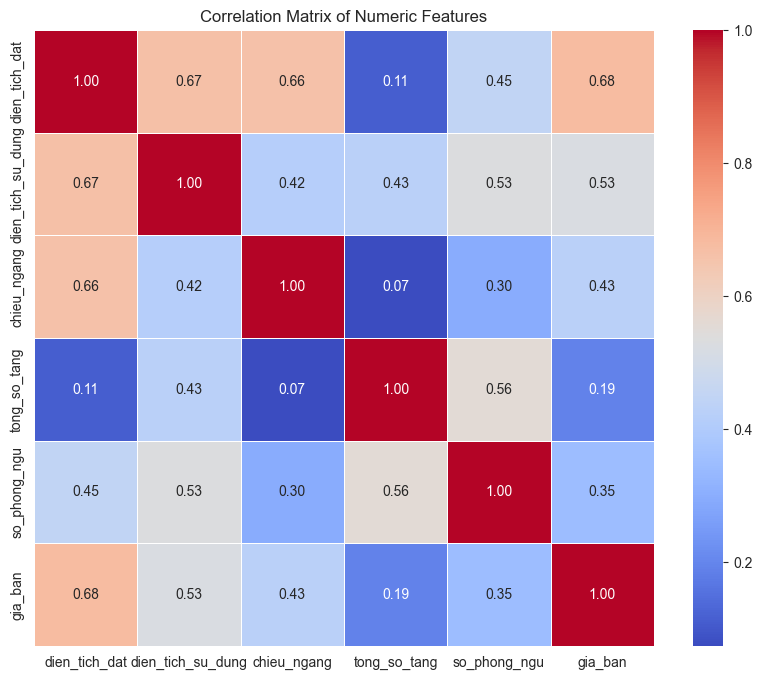

In [144]:
visualize_correlation(data)

**Xem hình dạng phân phối của dữ liệu**

In [145]:
def visualize_skewness_pandas(df):

    # Xác định danh sách cột và số lượng
    columns = df.select_dtypes(include=['number']).columns.tolist()
    num_cols = len(columns)
    num_columns_grid = 3 # Số cột trong lưới biểu đồ (layout)
    num_rows_grid = math.ceil(num_cols / num_columns_grid) # Tự động tính số hàng cần thiết

    # Cấu hình kích thước biểu đồ tổng thể
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(columns, start=1):
        plt.subplot(num_rows_grid, num_columns_grid, i)

        # Vẽ histogram kết hợp đường KDE (biểu thị mật độ phân phối)
        sns.histplot(df[column], kde=True)

        plt.title(f"Distribution of {column}", fontsize=12)
        plt.xlabel("") # Ẩn label trục X để biểu đồ thoáng hơn
        plt.ylabel("Frequency")

    # Tối ưu khoảng cách giữa các biểu đồ con
    plt.tight_layout()
    plt.show()

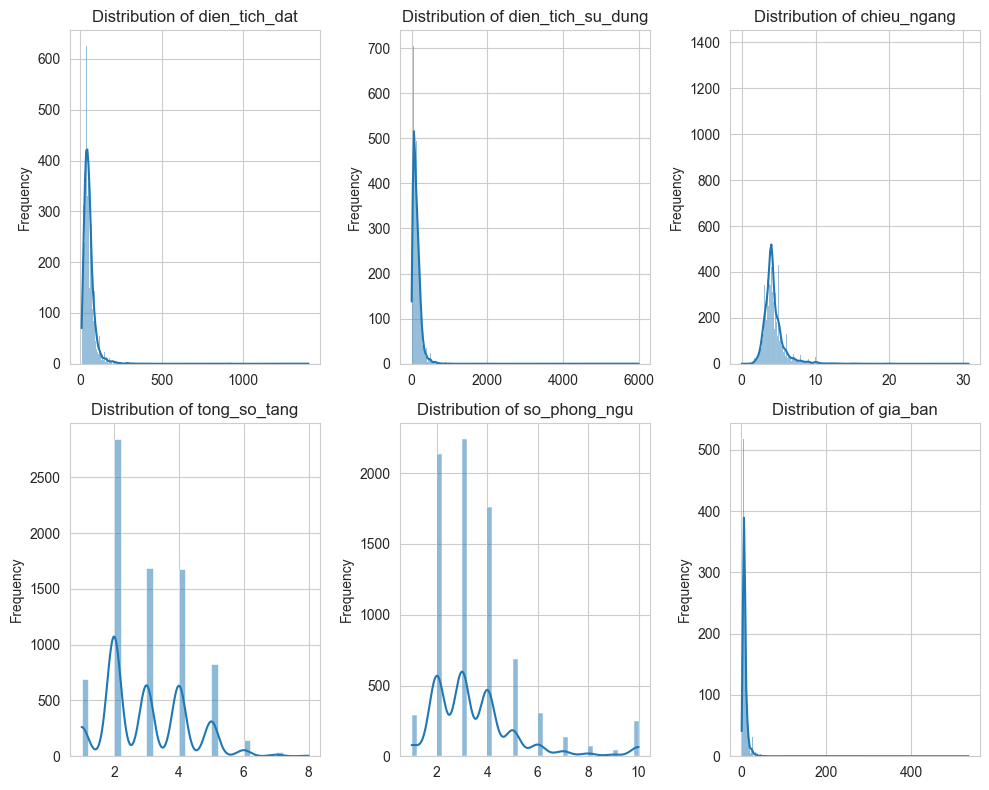

In [146]:
visualize_skewness_pandas(data)

**Kiểm tra outlier**

In [147]:
def visualize_outliers_pandas(df):

    # Xác định các cột số (numeric)
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

    # Tự động tính toán lưới biểu đồ (layout)
    num_plots = len(numeric_cols)
    num_cols_grid = 3 # Số cột biểu đồ mỗi hàng
    num_rows_grid = math.ceil(num_plots / num_cols_grid)

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 8))

    for i, column in enumerate(numeric_cols):
        plt.subplot(num_rows_grid, num_cols_grid, i + 1)

        # Vẽ Boxplot
        sns.boxplot(y=df[column])

        plt.title(f'Box Plot of {column}', fontsize=12)
        plt.ylabel('')

    # Hiển thị
    plt.tight_layout()
    plt.show()

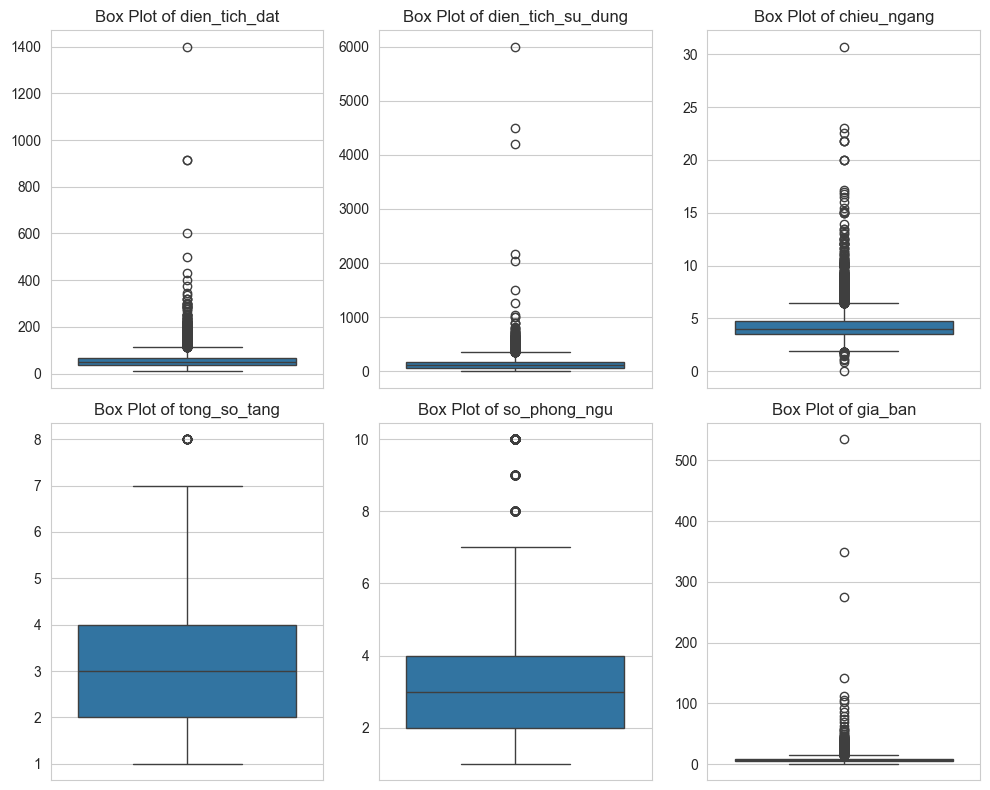

In [148]:
visualize_outliers_pandas(data)

**Xử lý outlier (Trimming)**

In [149]:
def trim_outliers(df, columns, lower_percentile=0.004, upper_percentile=0.996):
    """
    Xử lý outlier bằng phương pháp Trimming (Loại bỏ dòng) sử dụng Pandas.
    - columns: Danh sách các cột cần xử lý
    - lower_percentile: Ngưỡng dưới (0.0 đến 1.0)
    - upper_percentile: Ngưỡng trên (0.0 đến 1.0)
    """
    df_initial_count = len(df)

    # Tạo một bản sao để tránh SettingWithCopyWarning
    df_trimmed = df.copy()

    for col_name in columns:
        if col_name not in df_trimmed.columns:
            print(f"Warning: Column '{col_name}' not found in DataFrame. Skipping.")
            continue

        # Ensure the column is numeric before calculating quantiles
        if df_trimmed[col_name].dtype == 'object':
            df_trimmed[col_name] = pd.to_numeric(df_trimmed[col_name], errors='coerce')

        # Drop rows where the current column is NaN, as quantiles cannot be calculated reliably
        df_trimmed_for_quantile = df_trimmed.dropna(subset=[col_name])

        if len(df_trimmed_for_quantile) == 0:
            print(f"Warning: Column '{col_name}' became entirely NaN after numeric conversion. Cannot calculate quantiles.")
            continue

        # Tính toán giá trị tại các ngưỡng bách phân vị
        lower_limit = df_trimmed_for_quantile[col_name].quantile(lower_percentile)
        upper_limit = df_trimmed_for_quantile[col_name].quantile(upper_percentile)

        if pd.isna(lower_limit) or pd.isna(upper_limit):
            print(f"Warning: Quantile limits for '{col_name}' are NaN [{lower_limit} - {upper_limit}]. Skipping trimming for this column.")
            continue

        # Xác định các dòng là outlier để thống kê
        outliers = df_trimmed[(df_trimmed[col_name] < lower_limit) |
                              (df_trimmed[col_name] > upper_limit)]

        outlier_count = len(outliers)
        per_cent = (outlier_count / df_initial_count) * 100

        print(f"Cột {col_name}: Ngưỡng lọc [{lower_limit:.4f} - {upper_limit:.4f}]")
        print(f"Tỉ lệ loại bỏ: {per_cent:.4f}%")

        # Loại bỏ (Filter) các dòng vượt quá ngưỡng
        df_trimmed = df_trimmed[(df_trimmed[col_name] >= lower_limit) &
                                (df_trimmed[col_name] <= upper_limit)]

    print(f"Tổng số dòng sau khi lọc: {len(df_trimmed)} (Giảm {df_initial_count - len(df_trimmed)} dòng)")

    return df_trimmed

In [150]:
# Áp dụng trim outlier
lower_percentile=0.004
upper_percentile=0.8
cols_to_fix = ["dien_tich_su_dung", "chieu_ngang", "gia_ban"]
data = trim_outliers(data, cols_to_fix, lower_percentile, upper_percentile)

Cột dien_tich_su_dung: Ngưỡng lọc [5.9817 - 195.8147]
Tỉ lệ loại bỏ: 20.2549%
Cột chieu_ngang: Ngưỡng lọc [1.8439 - 4.6655]
Tỉ lệ loại bỏ: 16.0399%
Cột gia_ban: Ngưỡng lọc [1.5000 - 7.8000]
Tỉ lệ loại bỏ: 12.2918%
Tổng số dòng sau khi lọc: 4074 (Giảm 3850 dòng)


**Kết quả xử lý outliers**

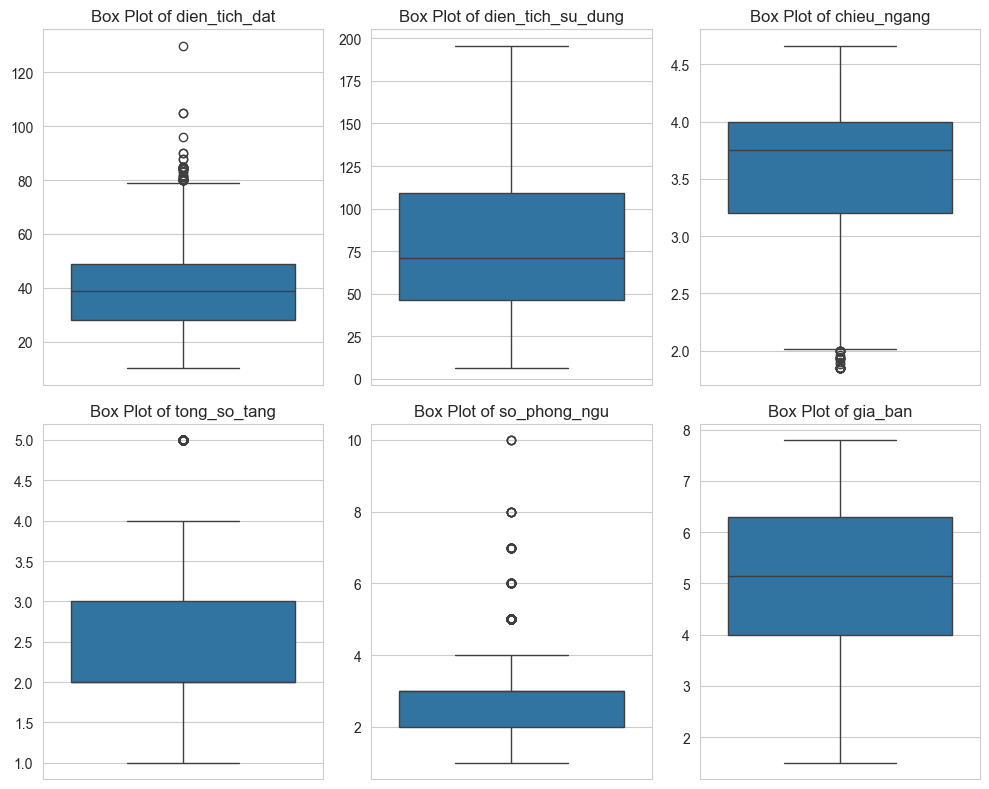

In [151]:
visualize_outliers_pandas(data)

**Export clean_data to csv**

In [152]:
clean_data_without_outliers_with_skewness = data.to_csv(
    'clean_data_without_outliers_with_skewness.csv', 
    index=False, 
    encoding='utf-8-sig'
)

**Xử lý skew các biến numerical**

Hàm xử lý và trả kết quả về là data đã được xử lý skew giúp model học tốt hơn

In [153]:
def analyze_numerical_skewness_pandas(df, skew_threshold=0.5):
    print("="*80)
    print("NUMERICAL VARIABLES SKEWNESS ANALYSIS (PANDAS)")
    print("="*80)

    # Lấy các cột số
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    results = {}

    for num_col in numeric_cols:
        # Tính skewness (Pandas bỏ qua NaN mặc định)
        skew_val = df[num_col].skew()

        if pd.isna(skew_val):
            skew_level = "N/A"
        elif abs(skew_val) <= 0.5:
            skew_level = "NORMAL (Nearly symmetric)"
        elif abs(skew_val) <= 1.0:
            skew_level = "MODERATE (Moderately skewed)"
        else:
            skew_level = "HIGH (Highly skewed)"

        results[num_col] = {
            "skewness": skew_val,
            "skew_level": skew_level,
            "needs_transform": abs(skew_val) > skew_threshold if not pd.isna(skew_val) else False
        }

        print(f"\n📊 {num_col}:")
        print(f"   Skewness: {skew_val:.4f} ({skew_level})")
        print(f"   Needs Transform: {'✅ YES' if results[num_col]['needs_transform'] else '❌ NO'}")

    return results

In [154]:
def transform_numerical_variables_pandas(df, transform_plan):
    df_transformed = df.copy()
    transformation_log = {}
    best_lambda = 1 # default if normal distribution
    best_lambda_gia_ban = 1 # Initialize best_lambda_gia_ban here with a default value

    print("\n" + "="*80)
    print("APPLYING TRANSFORMATIONS")
    print("="*80)

    for col_name, method in transform_plan.items():
        if method == "none" or col_name not in df.columns:
            continue

        try:
            if method == "log":
                df_transformed[f"{col_name}_log"] = np.log(df[col_name])
                new_col = f"{col_name}_log"

            elif method == "sqrt":
                df_transformed[f"{col_name}_sqrt"] = np.sqrt(df[col_name])
                new_col = f"{col_name}_sqrt"

            elif method == "boxcox":
                df_transformed[f"{col_name}_boxcox"], best_lambda = stats.boxcox(df[col_name])
                new_col = f"{col_name}_boxcox"
                if new_col == 'gia_ban_boxcox':
                    best_lambda_gia_ban = best_lambda

            # Kiểm tra skewness sau khi biến đổi
            skew_after = df_transformed[new_col].skew()
            transformation_log[col_name] = {"method": method, "new_col": new_col, "skew_after": skew_after}
            print(f"✅ Applied {method.upper()} transform to {col_name} → {new_col}")
            print(f"   Skewness after: {skew_after:.4f}")
            print(f"   Best_lambda: {best_lambda}")

        except Exception as e:
            print(f"❌ Error transforming {col_name}: {e}")

    return df_transformed, best_lambda_gia_ban

In [155]:
def complete_skew_transform_pipeline_pandas(df, numerical_skew_threshold=0.5):
    # Phân tích
    skew_results = analyze_numerical_skewness_pandas(df, numerical_skew_threshold)

    # Lập kế hoạch biến đổi
    transform_plan = {}
    for col_name, stats in skew_results.items():
        if stats.get("needs_transform"):
            skew_val = abs(stats["skewness"])
            if skew_val > 2.0: transform_plan[col_name] = "log"
            elif skew_val > 1.0: transform_plan[col_name] = "sqrt"
            elif skew_val > 0.5: transform_plan[col_name] = "boxcox"

    # Initialize df_processed and best_lambda_gia_ban before the conditional block
    df_processed = df.copy()
    # best_lambda_gia_ban = 1

    # Thực thi
    if transform_plan:
        df_processed, best_lambda_gia_ban = transform_numerical_variables_pandas(df, transform_plan)
    else:
        print("No transformations needed.")

    print("\n" + "="*80)
    print(f"Original columns: {len(df.columns)}")
    print(f"New columns: {len(df_processed.columns)}")

    return df_processed, best_lambda_gia_ban


In [156]:
# Sử dụng
df_transformed, best_lambda_gia_ban = complete_skew_transform_pipeline_pandas(data)
print(f"Kích thước dữ liệu sau transform: {df_transformed.shape}")
print(f"Best_lambda_gia_ban: {best_lambda_gia_ban}")
df_transformed.head(5)

NUMERICAL VARIABLES SKEWNESS ANALYSIS (PANDAS)

📊 dien_tich_dat:
   Skewness: 0.4818 (NORMAL (Nearly symmetric))
   Needs Transform: ❌ NO

📊 dien_tich_su_dung:
   Skewness: 0.5951 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 chieu_ngang:
   Skewness: -0.6561 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 tong_so_tang:
   Skewness: 0.6151 (MODERATE (Moderately skewed))
   Needs Transform: ✅ YES

📊 so_phong_ngu:
   Skewness: 1.3105 (HIGH (Highly skewed))
   Needs Transform: ✅ YES

📊 gia_ban:
   Skewness: -0.1996 (NORMAL (Nearly symmetric))
   Needs Transform: ❌ NO

APPLYING TRANSFORMATIONS
✅ Applied BOXCOX transform to dien_tich_su_dung → dien_tich_su_dung_boxcox
   Skewness after: -0.0543
   Best_lambda: 0.42520887045601974
✅ Applied BOXCOX transform to chieu_ngang → chieu_ngang_boxcox
   Skewness after: -0.1178
   Best_lambda: 2.5397916538204854
✅ Applied BOXCOX transform to tong_so_tang → tong_so_tang_boxcox
   Skewness after: -0.0079
   Best_lambda: 0.3108

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban,dien_tich_su_dung_boxcox,chieu_ngang_boxcox,tong_so_tang_boxcox,so_phong_ngu_sqrt
0,Nhà hẻm cách đường mặt tiền 20m,Nhà hẻm cách đường mặt tiền 20m\nNhà ở khu vực...,18.0,18.0,3.000000,1.0,2.0,nha_ngo_hem,da_co_so,chua_xac_dinh,bac,hien_trang_khac,phuong_12_quan_binh_thanh,phuong_binh_thanh,2.850,5.686264,6.018222,0.000000,1.414214
12,Nhà hẻm cách mặt tiền 20m,Nhà trong hẻm cách đường lớn 20m\nKhu dân cư y...,20.0,20.0,3.076923,2.0,2.0,nha_ngo_hem,chua_xac_dinh,chua_xac_dinh,bac,hien_trang_khac,phuong_12_quan_binh_thanh,phuong_binh_thanh,2.850,6.054559,6.444068,0.773497,1.414214
13,"Nhà mới xây 3x11,5, 2 tầng, diện tích sử dụng ...","Nhà mới xây, 2 phòng ngủ rộng + ban công rộng,...",34.0,68.0,2.956522,2.0,2.0,nha_ngo_hem,da_co_so,noi_that_cao_cap,dong_bac,hien_trang_khac,phuong_11_quan_binh_thanh,phuong_binh_loi_trung,5.959,11.793012,5.784834,0.773497,1.414214
16,Nơ Trang Long – 2 tầng đúc 2PN 2WC full nội th...,📣🔥 QUỐC KIỆT NHÀ PHỐ 🔥📍\n\nMột buổi sáng mở cử...,20.0,40.0,3.333333,2.0,2.0,nha_ngo_hem,da_co_so,noi_that_day_du,dong_bac,hien_trang_khac,phuong_13_quan_binh_thanh,phuong_binh_loi_trung,3.900,8.935976,7.985514,0.773497,1.414214
17,"Gấp bán ""6.7 Tỷ giảm về 6.1 Tỷ"" - Bán đất tặng...",Vị trí Hoàng Hoa Thám P.6 Bình Thạnh\n+ Diện t...,50.0,90.0,4.166667,2.0,2.0,nha_ngo_hem,da_co_so,hoan_thien_co_ban,tay,hem_xe_hoi,phuong_6_quan_binh_thanh,phuong_binh_loi_trung,6.190,13.583467,14.374761,0.773497,1.414214


**Xem biểu đồ phân bố dữ liệu các cột sau khi đã xử lý skew**

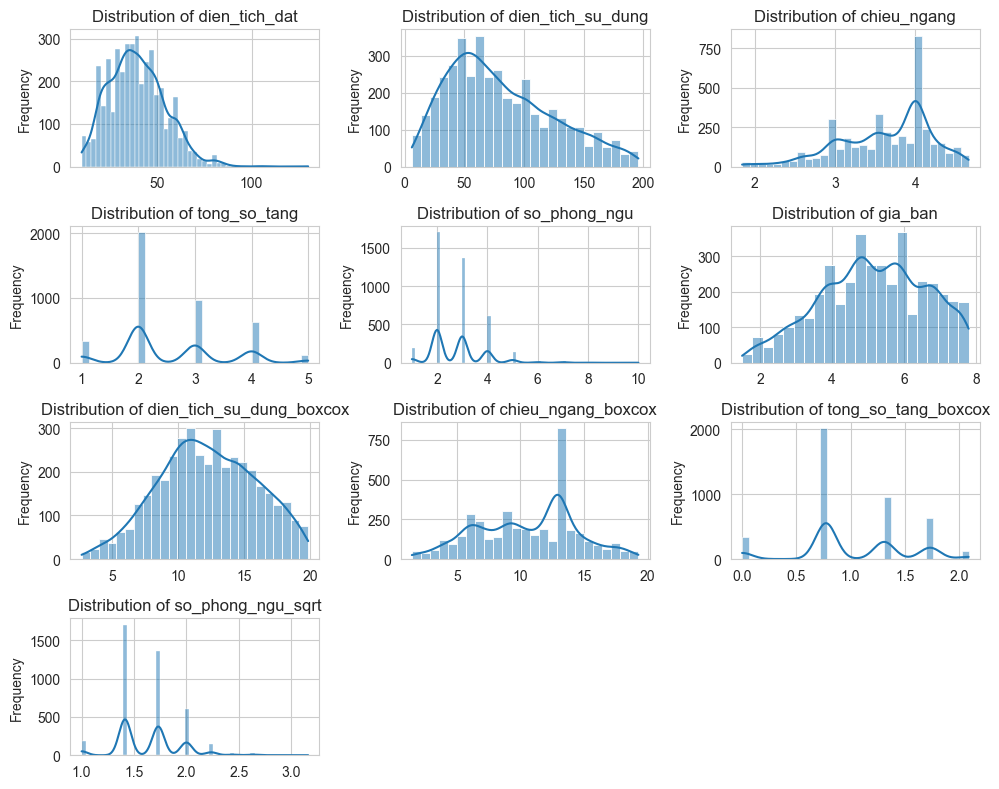

In [157]:
visualize_skewness_pandas(df_transformed)

**Kiểm tra outlier sau xử lý skew**

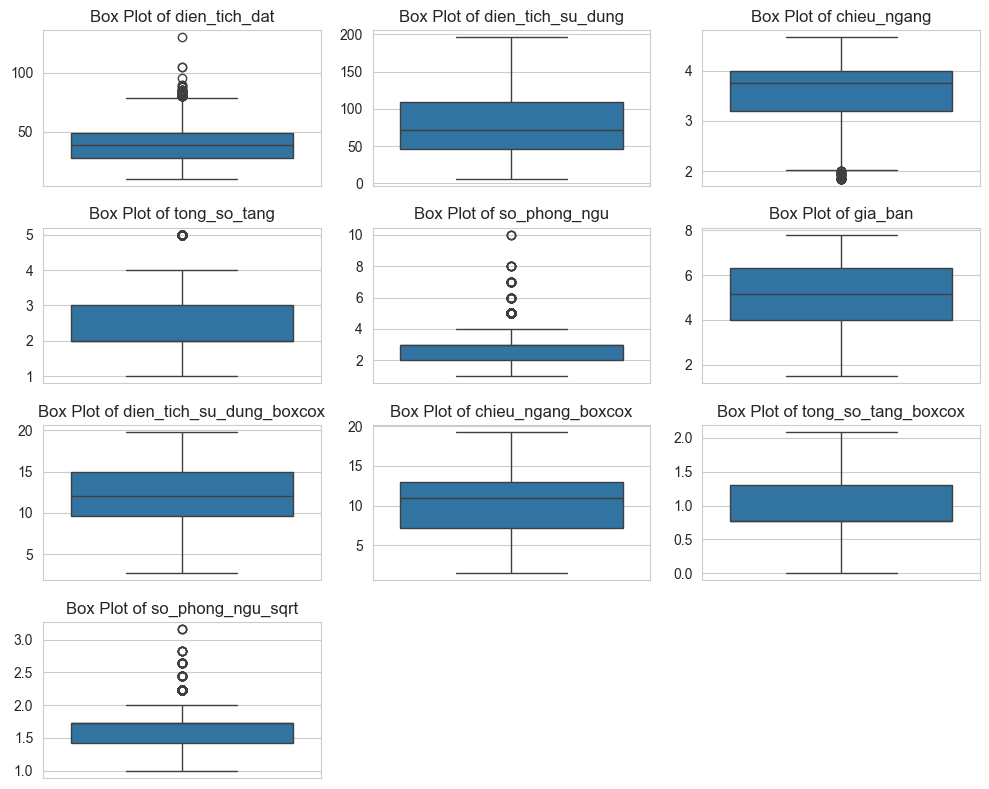

In [158]:
visualize_outliers_pandas(df_transformed)

**Xác định các biến numerical và categorical để chuẩn hóa trước khi training**

In [159]:
def get_numerical_for_ml(df):
    """
    Lấy danh sách các cột số cho ML, ưu tiên các cột đã được biến đổi (_log, _sqrt, _boxcox)
    và loại bỏ hoàn toàn các cột liên quan đến 'gia_ban'.
    """
    # Lấy tất cả các cột có kiểu dữ liệu là số (int, float, long, v.v.)
    all_numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

    # Xác định các cột đã được biến đổi bằng Regex
    pattern = r"^(.*)(_log|_sqrt|_boxcox)$"
    transformed_map = {}

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        if match:
            root_name = match.group(1)
            transformed_map[root_name] = col

    # Logic lọc và ưu tiên
    numerical_cols_for_ml = []
    seen_roots = set()

    for col in all_numerical_cols:
        match = re.match(pattern, col)
        # Nếu là cột biến đổi thì lấy root, nếu không thì lấy chính nó
        root = match.group(1) if match else col

        # Kiểm tra nếu root chứa "gia_ban" thì bỏ qua hoàn toàn (Target leakage)
        if "gia_ban" in root:
            continue

        if root not in seen_roots:
            # Nếu gốc này có bản biến đổi trong map, lấy bản biến đổi đó
            if root in transformed_map:
                numerical_cols_for_ml.append(transformed_map[root])
            else:
                # Nếu không có bản biến đổi, lấy tên gốc
                numerical_cols_for_ml.append(root)

            seen_roots.add(root)

    return numerical_cols_for_ml

**Chọn biến numerical và categorical**

In [160]:
numerical_features = get_numerical_for_ml(df_transformed)
categorical_features = df_transformed.select_dtypes(include=['object']).drop(['tieu_de', 'mo_ta'], axis=1).columns.tolist()

**Chuẩn hóa các feature --> tạo data đã qua chuẩn hóa**
- Áp dụng Robust Scaler cho các biến numerical
- Áp dụng OneHot Encoder cho các biến categorical


In [161]:
# Pipeline xử lý số: Điền khuyết (Imputer) -> Chuẩn hóa (RobustScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0)))
])

In [162]:
# Helper function to convert to string (replaces lambda for pickling compatibility)
def convert_to_string(x):
    return x.astype(str)

# Redefine categorical_transformer to include a string conversion step
categorical_transformer_fixed = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('to_string', FunctionTransformer(convert_to_string, validate=False)), # Use the named function here
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Redefine preprocessor with the fixed categorical_transformer
preprocessor_fixed = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer_fixed, categorical_features)
    ])

**Train/ Test Split**

In [163]:
# Tách đặc trưng và nhãn
transformed_target_cols = [col for col in df_transformed.columns if 'gia_ban_' in col]
if transformed_target_cols:
    tf_target_col = transformed_target_cols[0]
else:
    tf_target_col = 'gia_ban'

X = df_transformed[numerical_features + categorical_features]
y = df_transformed[tf_target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data count: {len(X_train)}")
print(f"Testing data count: {len(X_test)}")

Training data count: 3259
Testing data count: 815


**Huấn luyện và Đánh giá Model**

In [164]:
def build_and_evaluate_models(X_train, y_train, X_test, y_test, param_grid=False, transformed_target_col=None, best_lambda_gia_ban=None):

    # Định nghĩa models
    lr   = LinearRegression()

    rf   = RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_leaf=1, min_samples_split=3, max_features=0.2, max_samples=1.0, random_state=42)

    xgb  = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=0)

    # lgbm = LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, objective="regression", random_state=42, verbose=-1)
    lgbm = LGBMRegressor(n_estimators=100, random_state=42)

    gbt  = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

    # svm  = SVR(kernel='rbf', C=1000, epsilon=0.1)
    svm  = SVR(kernel='rbf', C=100, epsilon=0.2, gamma=0.01)

    models      = [lr, rf, xgb, lgbm, gbt, svm]

    model_names = ["Linear Regression", "Random Forest Regressor",
                   "XGBoost", "LightGBM Regressor", "Gradient-Boosted Trees Regressor", "SVM (RBF Kernel)"]

    # Param grids
    param_grids = [
        {"model__fit_intercept": [True, False]},                                                                                                                 # lr
        {"model__n_estimators": [20, 30, 40, 50, 100], "model__max_depth": [3, 4, 5, 6, 10, 15, 30, None], "model__min_samples_split": [3],
         "model__min_samples_leaf": [1], "model__max_samples": [0.8, 1.0], "model__max_features": [0.2]},                                                        # rf
        {"model__n_estimators": [20, 30, 40, 50, 100], "model__max_depth": [3, 4, 5, 6, 10, 15, 30], "model__learning_rate": [0.01, 0.1] },                      # xgb
        {"model__n_estimators": [100, 200], "model__max_depth": [3, 4, 5, 6, 10, 15, 30], "model__learning_rate": [0.01, 0.1], "model__num_leaves": [31, 60]},   # lgbm
        {"model__n_estimators": [20, 30, 40, 50, 100], "model__max_depth": [3, 4, 5, 6, 10, 15, 30], "model__learning_rate": [0.01, 0.1]},                       # gbt
        {"model__C": [100, 1000, 10000], "model__epsilon": [0.01, 0.1, 0.2, 0.5], "model__gamma": ['scale', 'auto', 0.01, 0.1], "model__kernel": ['rbf']}        # svm
        ]


    # Inverse transform helper
    def inverse_transform(preds):
        # Convert back to original scale
        if transformed_target_col == 'gia_ban':
            return preds
        elif transformed_target_col == 'gia_ban_log':
            return np.exp(preds)
        elif transformed_target_col == 'gia_ban_sqrt':
            return np.power(preds, 2)
        elif transformed_target_col == 'gia_ban_boxcox':
            if best_lambda_gia_ban == 0:
                return np.exp(preds)
            else:
                return inv_boxcox(preds, best_lambda_gia_ban)
        else:
            return preds

    # Vòng lặp train / evaluate
    results          = {}
    trained_models   = []
    all_predictions  = []

    for i, (model, name) in enumerate(zip(models, model_names)):
        #
        pipe = Pipeline(steps=[("preprocessor", preprocessor_fixed),
                               ("model", model)])

        if param_grid:
            search = GridSearchCV(
                pipe,
                param_grids[i],
                cv=5,
                # scoring="neg_root_mean_squared_error",
                scoring={
                    "r2": "r2",
                    "mae": "neg_mean_absolute_error"
                },
                refit="mae",  # ưu tiên mae thấp nhất
                n_jobs=-1
                # refit="r2",  # ưu tiên R² cao nhất
                # refit=True
            )
            search.fit(X_train, y_train)
            fitted_pipe  = search.best_estimator_
            best_params  = search.best_params_
            print(f"\n[{name}] Best params: {best_params}")
        else:
            pipe.fit(X_train, y_train)
            fitted_pipe = pipe

        trained_models.append(fitted_pipe)

        # Predict + inverse transform
        raw_preds       = fitted_pipe.predict(X_test)
        final_preds     = inverse_transform(raw_preds)
        all_predictions.append(final_preds)

        # Metrics trên original scale
        rmse = builtins.round(np.sqrt(mean_squared_error(y_test, final_preds)), 3)
        mae  = builtins.round(mean_absolute_error(y_test, final_preds), 3)
        r2   = builtins.round(r2_score(y_test, final_preds), 3)

        results[name] = {"R2": r2, "MAE": mae, "RMSE": rmse}

        print(f"\nMetrics for model {name}:")
        print(f"  RMSE      : {rmse}")
        print(f"  MAE       : {mae}")
        print(f"  R-squared : {r2}")

        # Scatter plot actual vs predicted
        pdf = pd.DataFrame({"gia_ban": y_test, "final_prediction": final_preds})
        plt.figure(figsize=(10, 8))
        sns.scatterplot(x="gia_ban", y="final_prediction", data=pdf, alpha=0.6)
        min_val = min(pdf["gia_ban"].min(), pdf["final_prediction"].min())
        max_val = max(pdf["gia_ban"].max(), pdf["final_prediction"].max())
        plt.plot([min_val, max_val], [min_val, max_val],
                 color="red", linestyle="--", linewidth=2)
        plt.xlabel("Actual Price")
        plt.ylabel("Predicted Price")
        plt.title(f"Actual vs. Predicted Prices — {name}")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

    # Bảng so sánh
    print("\nBảng so sánh kết quả:")
    print(pd.DataFrame(results).T.sort_values("MAE"))

    if param_grid:
        return trained_models, model_names, all_predictions
    else:
        return trained_models, model_names, all_predictions


Metrics for model Linear Regression:
  RMSE      : 0.87
  MAE       : 0.687
  R-squared : 0.648


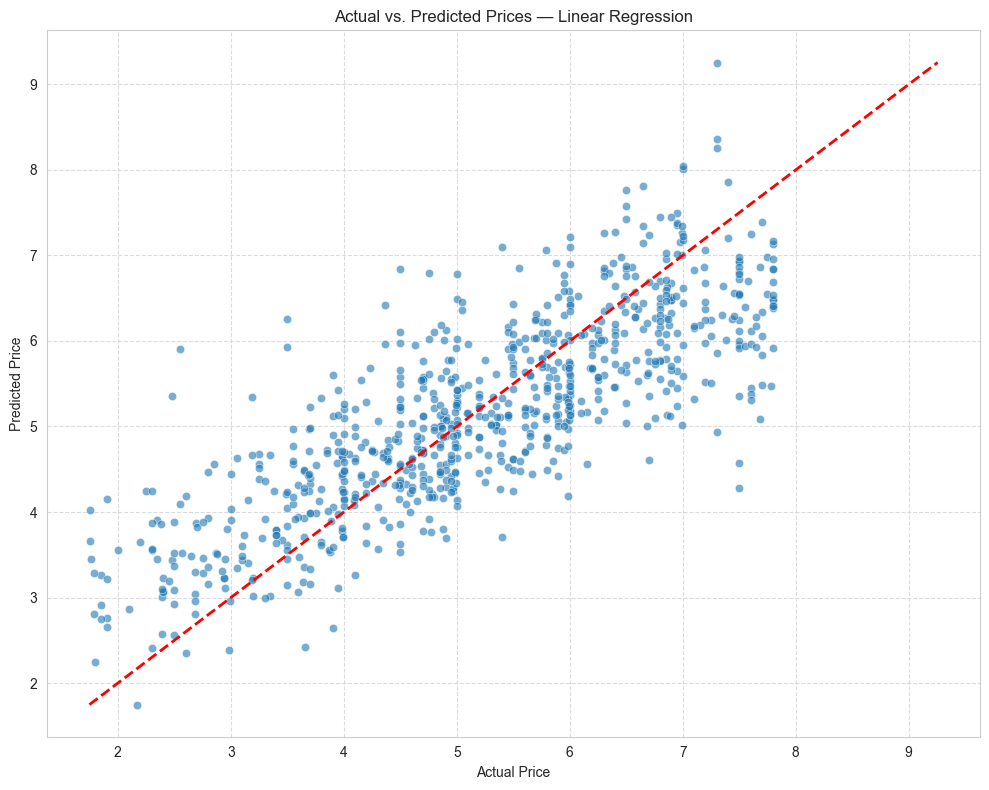


Metrics for model Random Forest Regressor:
  RMSE      : 0.76
  MAE       : 0.581
  R-squared : 0.732


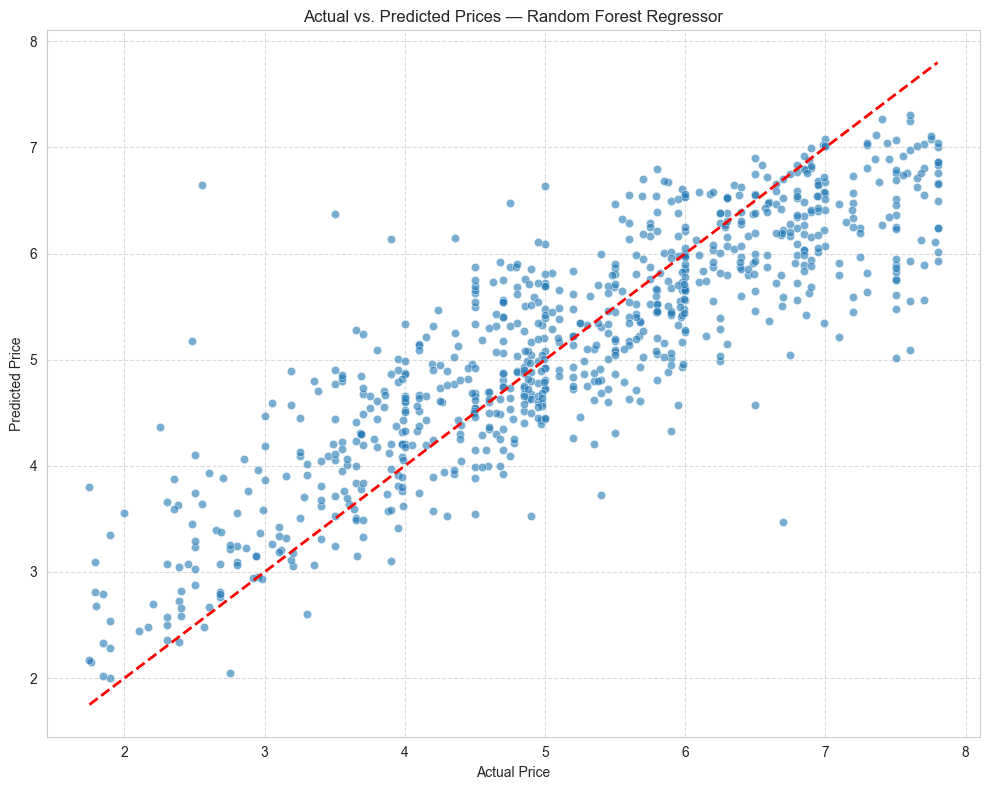


Metrics for model XGBoost:
  RMSE      : 0.755
  MAE       : 0.574
  R-squared : 0.735


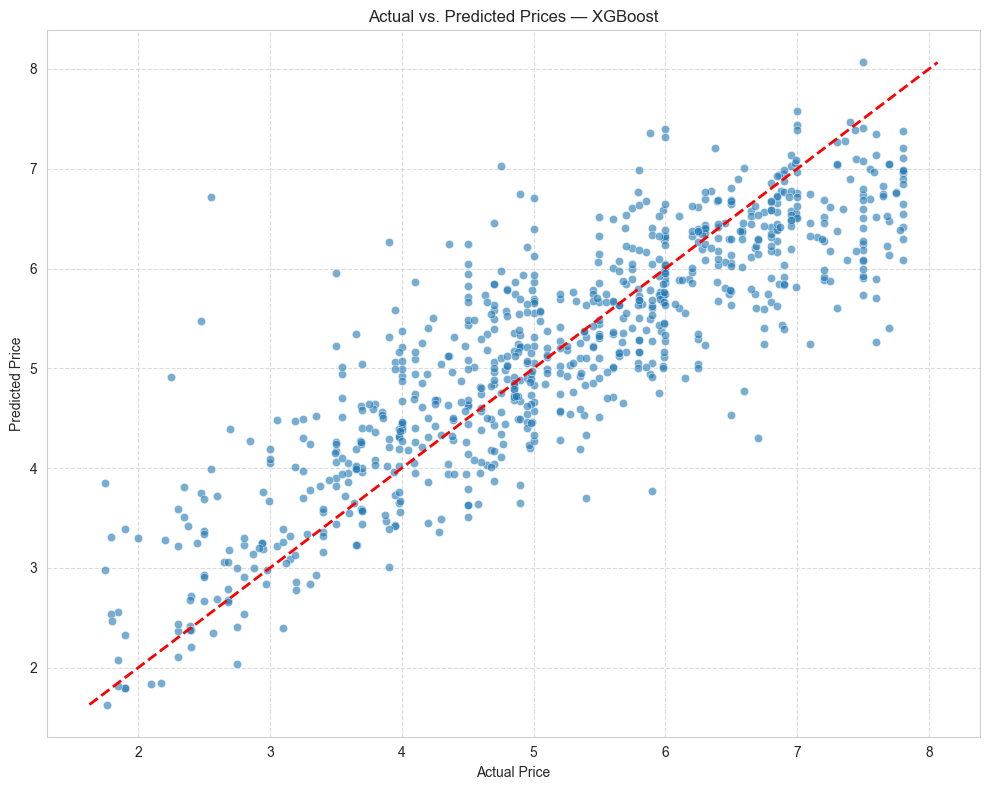

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 3259, number of used features: 84
[LightGBM] [Info] Start training from score 5.142475

Metrics for model LightGBM Regressor:
  RMSE      : 0.763
  MAE       : 0.58
  R-squared : 0.73


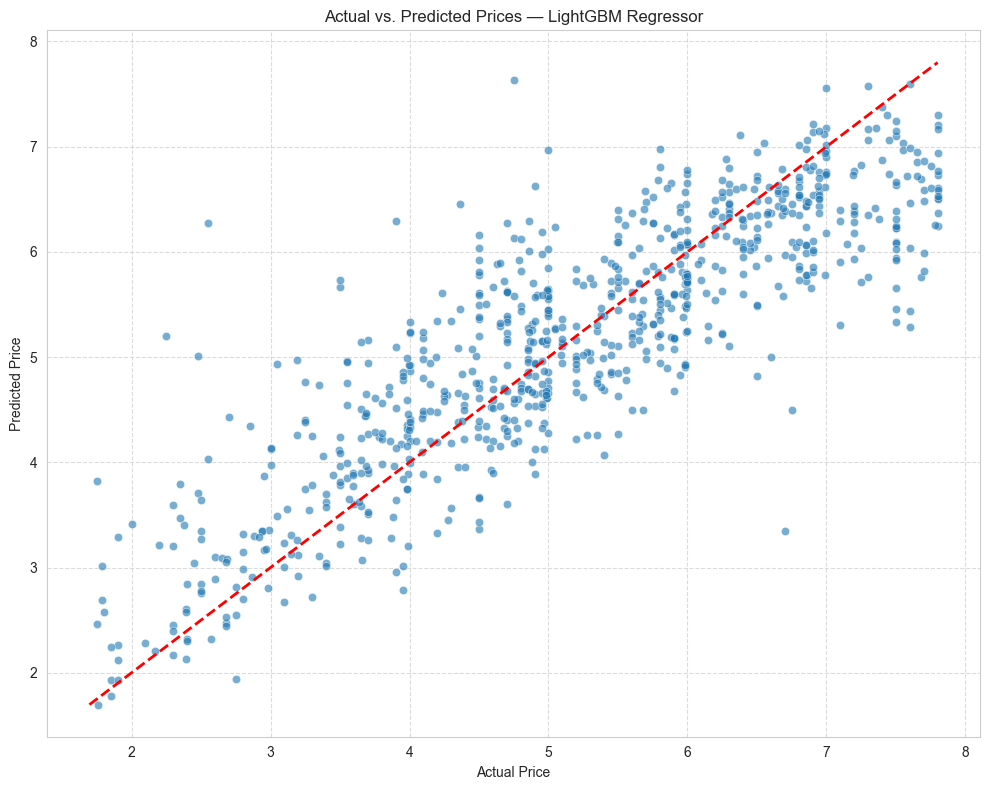


Metrics for model Gradient-Boosted Trees Regressor:
  RMSE      : 0.781
  MAE       : 0.6
  R-squared : 0.716


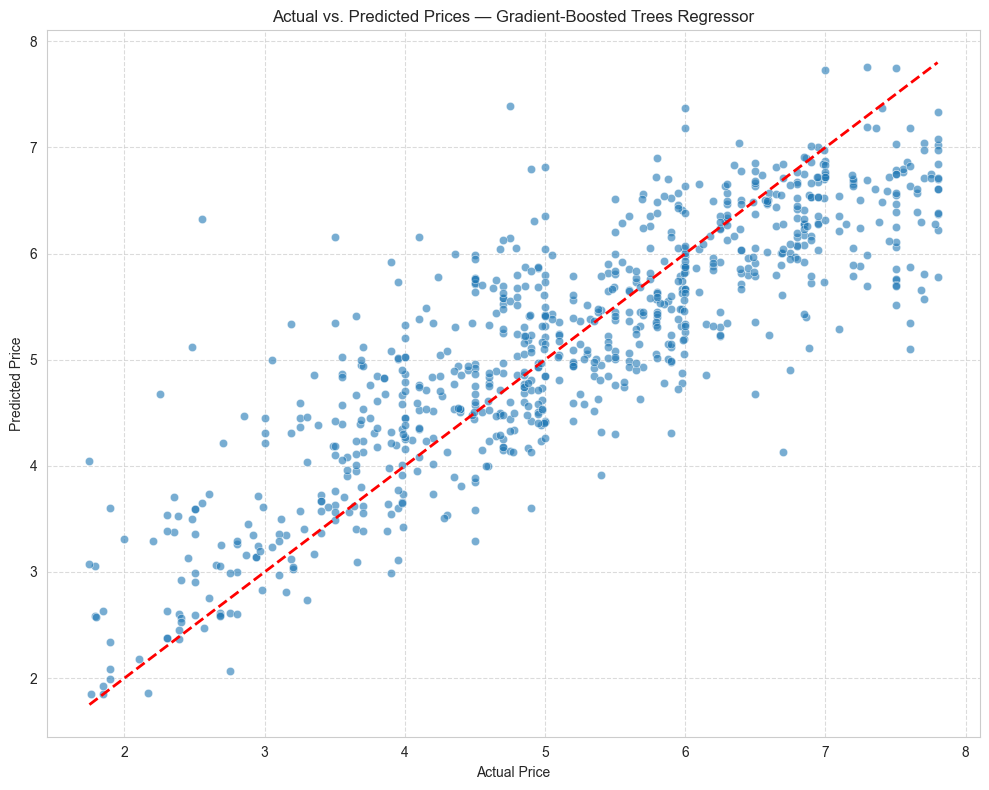


Metrics for model SVM (RBF Kernel):
  RMSE      : 0.822
  MAE       : 0.631
  R-squared : 0.686


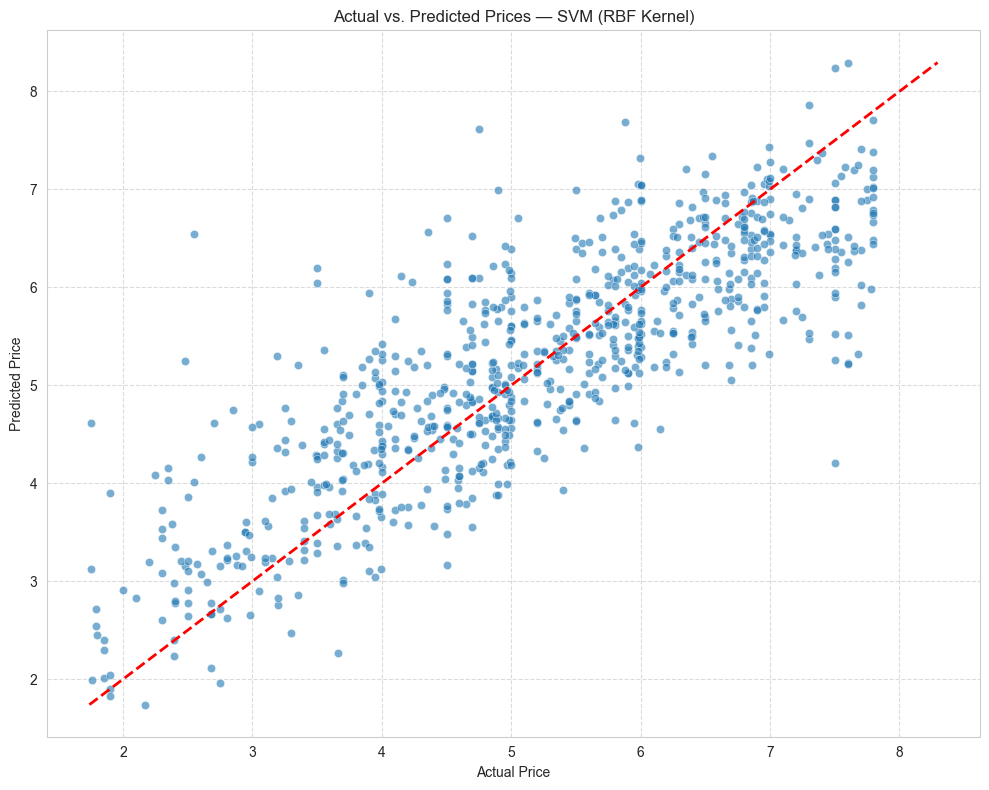


Bảng so sánh kết quả:
                                     R2    MAE   RMSE
XGBoost                           0.735  0.574  0.755
LightGBM Regressor                0.730  0.580  0.763
Random Forest Regressor           0.732  0.581  0.760
Gradient-Boosted Trees Regressor  0.716  0.600  0.781
SVM (RBF Kernel)                  0.686  0.631  0.822
Linear Regression                 0.648  0.687  0.870


In [165]:
# Không tuning
models, names, preds = build_and_evaluate_models(
    X_train, y_train, X_test, y_test,
    param_grid=False,
    transformed_target_col=tf_target_col,
)


**Nhận xét:**\
**XGBoost là model tốt nhất so với các model còn lại (xét theo RMSE, MAE thấp nhất, R-squared cao nhất)**

| Model                                                | R-squared | MAE       | RMSE      |
| :--------------------------------------------------- | :-------- | :-------- | :-------- |
| XGBoost                                              | 0.735     | 0.574     | 0.755     |
| LightGBM                                             | 0.730     | 0.580     | 0.763     |
| Random Forest Regressor                              | 0.732     | 0.581     | 0.760     |
| Gradient-Boosted Trees                               | 0.716     | 0.600     | 0.781     |
| SVM (RBF Kernel)                                     | 0.686     | 0.631     | 0.822     |
| Linear Regression                                    | 0.648     | 0.687     | 0.870     |


**Trích xuất đầy đủ thông tin tập test data gồm giá bán và giá chẩn đoán**

In [166]:
# Lấy predicted data
predictions = pd.DataFrame(preds[0], index=y_test.index)
predictions.columns = ["final_prediction"]

# Tạo df_test_final
df_test_final = df_transformed.join(predictions, how='inner')
df_test_final = df_test_final[data.columns.tolist() + predictions.columns.tolist()]

# Hiển thị final test data
df_test_final.head(1)

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban,final_prediction
21,ĐINH BỘ LĨNH NHÀ MỚI 3 TẦNG - 2 PN 2WC - HẺM A...,📣🔥 QUỐC KIỆT NHÀ PHỐ 🔥📍\n\n\nNằm trên trục Đin...,14.0,42.0,3.5,3.0,2.0,nha_ngo_hem,da_co_so,noi_that_day_du,tay_nam,hien_trang_khac,phuong_26_quan_binh_thanh,phuong_binh_thanh,2.75,3.887287


**Export data "anomaly_detection_from_xgboost_prediction" to csv --> Project1 - Ex1 - Anomaly detection**

In [167]:
anomaly_detection_from_xgboost_prediction = df_test_final.to_csv(
    'anomaly_detection_from_xgboost_prediction.csv', 
    index=False, 
    encoding='utf-8-sig'
)

**Lưu model để tái sử dụng**

In [168]:
# Lưu mô hình (đã gồm scaler)
model_filename = 'model_gia_nha_xgboost.pkl'
xgb_index = names.index('XGBoost')
model_to_save = models[xgb_index]

joblib.dump(model_to_save, model_filename)

print(f"Đã lưu mô hình vào file: {model_filename}")


Đã lưu mô hình vào file: model_gia_nha_xgboost.pkl


**Tạo dữ liệu mẫu cho new predict**

In [169]:
# Tạo dữ liệu giả lập
new_data = {
    'id_nha': [0, 1, 2, 3, 4],
    'dien_tich_dat': [32, 41, 40, 40, 45],
    'dien_tich_su_dung': [64, 82, 120, 120, 90],
    'chieu_ngang': [3.5, 5, 5, 4, 4.5],
    'tong_so_tang': [1, 2, 3, 3, 2],
    'so_phong_ngu': [3, 3, 4, 4, 3],
    'loai_hinh': ['nha_pho_lien_ke', 'nha_ngo_hem', 'nha_mat_pho_mat_tien', 'nha_ngo_hem', 'nha_ngo_hem'],
    'giay_to_phap_ly': ['da_co_so', 'da_co_so', 'da_co_so', 'da_co_so', 'da_co_so'],
    'tinh_trang_noi_that': ['noi_that_cao_cap', 'noi_that_day_du', 'noi_that_cao_cap', 'noi_that_day_du', 'noi_that_cao_cap'],
    'huong_cua_chinh': ['dong_nam', 'dong_nam', 'dong_nam', 'dong_bac', 'nam'],
    'dac_diem': ['hem_xe_hoi', 'hem_xe_hoi', 'hem_xe_hoi', 'hem_xe_hoi', 'hem_xe_hoi'],
    'dia_chi_cu': ['phuong_12_quan_go_vap', 'phuong_3_quan_go_vap', 'phuong_3_quan_go_vap', 'phuong_13_quan_phu_nhuan', 'phuong_7_quan_binh_thanh'],
    'dia_chi_moi': ['phuong_an_hoi_tay', 'phuong_hanh_thong', 'phuong_hanh_thong', 'phuong_phu_nhuan', 'phuong_binh_thanh'],
    'gia_ban': [5.56, 4.35, 7.6, 6.3, 6.7]

}

# Khởi tạo DataFrame
df_sample = pd.DataFrame(new_data)

# Đặt id_nha làm index (giống như cách bạn đang làm với df_transformed)
df_sample.set_index('id_nha', inplace=True)

print("DataFrame mẫu bất động sản:")
df_sample

DataFrame mẫu bất động sản:


,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban
id_nha,,,,,,,,,,,,,
0,32,64,3.5,1,3,nha_pho_lien_ke,da_co_so,noi_that_cao_cap,dong_nam,hem_xe_hoi,phuong_12_quan_go_vap,phuong_an_hoi_tay,5.56
1,41,82,5.0,2,3,nha_ngo_hem,da_co_so,noi_that_day_du,dong_nam,hem_xe_hoi,phuong_3_quan_go_vap,phuong_hanh_thong,4.35
2,40,120,5.0,3,4,nha_mat_pho_mat_tien,da_co_so,noi_that_cao_cap,dong_nam,hem_xe_hoi,phuong_3_quan_go_vap,phuong_hanh_thong,7.60
3,40,120,4.0,3,4,nha_ngo_hem,da_co_so,noi_that_day_du,dong_bac,hem_xe_hoi,phuong_13_quan_phu_nhuan,phuong_phu_nhuan,6.30
4,45,90,4.5,2,3,nha_ngo_hem,da_co_so,noi_that_cao_cap,nam,hem_xe_hoi,phuong_7_quan_binh_thanh,phuong_binh_thanh,6.70


**Xử lý dữ liệu trước khi predict**

In [170]:
df_X_test_new = df_sample.drop(columns=['gia_ban'])
df_X_test_new['dien_tich_su_dung_boxcox'], _ = stats.boxcox(df_X_test_new['dien_tich_su_dung'])
df_X_test_new['chieu_ngang_boxcox'], _ = stats.boxcox(df_X_test_new['chieu_ngang'])
df_X_test_new['tong_so_tang_boxcox'], _ = stats.boxcox(df_X_test_new['tong_so_tang'])
df_X_test_new['so_phong_ngu_sqrt'] = np.sqrt(df_X_test_new['so_phong_ngu'])

df_X_test_new = df_X_test_new[numerical_features + categorical_features]
df_y_test_new = df_sample['gia_ban']

**Load model**

In [171]:
# Khi cần tái sử dụng
# Tải mô hình lên
loaded_model = joblib.load('model_gia_nha_xgboost.pkl')

**Predict**

In [172]:
# Dự báo với dữ liệu mới (df_X_test_new)

df_prediction_new = loaded_model.predict(df_X_test_new)

df_prediction_new = pd.DataFrame(df_prediction_new, index=df_X_test_new.index)
df_prediction_new.columns = ["final_prediction"]

df_new_sample_final = df_sample.join(df_prediction_new, how='inner')
df_new_sample_final = df_new_sample_final[df_sample.columns.tolist() + df_prediction_new.columns.tolist()]

In [173]:
df_new_sample_final

,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban,final_prediction
id_nha,,,,,,,,,,,,,,
0,32,64,3.5,1,3,nha_pho_lien_ke,da_co_so,noi_that_cao_cap,dong_nam,hem_xe_hoi,phuong_12_quan_go_vap,phuong_an_hoi_tay,5.56,6.097761
1,41,82,5.0,2,3,nha_ngo_hem,da_co_so,noi_that_day_du,dong_nam,hem_xe_hoi,phuong_3_quan_go_vap,phuong_hanh_thong,4.35,5.796712
2,40,120,5.0,3,4,nha_mat_pho_mat_tien,da_co_so,noi_that_cao_cap,dong_nam,hem_xe_hoi,phuong_3_quan_go_vap,phuong_hanh_thong,7.60,7.694506
3,40,120,4.0,3,4,nha_ngo_hem,da_co_so,noi_that_day_du,dong_bac,hem_xe_hoi,phuong_13_quan_phu_nhuan,phuong_phu_nhuan,6.30,7.376794
4,45,90,4.5,2,3,nha_ngo_hem,da_co_so,noi_that_cao_cap,nam,hem_xe_hoi,phuong_7_quan_binh_thanh,phuong_binh_thanh,6.70,6.184264


In [174]:
r2 = r2_score(df_y_test_new, df_prediction_new)
mae = mean_absolute_error(df_y_test_new, df_prediction_new)
rmse = np.sqrt(mean_squared_error(df_y_test_new, df_prediction_new))

print(f"R-squared: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

R-squared: 0.3643383867597271
MAE: 0.7343017845153812
RMSE: 0.8736776498026785


# **Bài toán số 2 - Recommendation**

**Sử dụng data đã predict của tập test với model XGBoost**

In [175]:
df_pr1_2 = pd.read_csv(
    'anomaly_detection_from_xgboost_prediction.csv', 
    encoding='utf-8-sig'
)

In [176]:
# df_pr1_2 = df_test_final.copy()
df_pr1_2.head(5)

,tieu_de,mo_ta,dien_tich_dat,dien_tich_su_dung,chieu_ngang,tong_so_tang,so_phong_ngu,loai_hinh,giay_to_phap_ly,tinh_trang_noi_that,huong_cua_chinh,dac_diem,dia_chi_cu,dia_chi_moi,gia_ban,final_prediction
0,ĐINH BỘ LĨNH NHÀ MỚI 3 TẦNG - 2 PN 2WC - HẺM A...,📣🔥 QUỐC KIỆT NHÀ PHỐ 🔥📍\n\n\nNằm trên trục Đin...,14.0,42.0,3.500000,3.0,2.0,nha_ngo_hem,da_co_so,noi_that_day_du,tay_nam,hien_trang_khac,phuong_26_quan_binh_thanh,phuong_binh_thanh,2.75,3.887287
1,Chính chů cân bán nhà binh thanh,- Bán nhà võ duy ninh bình thanh phương 22\n- ...,38.7,65.5,3.096000,2.0,2.0,nha_ngo_hem,da_co_so,chua_xac_dinh,dong_nam,nha_no_hau,phuong_22_quan_binh_thanh,phuong_thanh_my_tay,5.45,4.521294
2,Nhà bán bình thạnh,💢 Nhà Bình Thạnh.đường Huỳnh Đình Hai . HCM\n\...,31.0,31.0,2.583333,2.0,1.0,nha_ngo_hem,da_co_so,hoan_thien_co_ban,nam,hien_trang_khac,phuong_24_quan_binh_thanh,phuong_binh_thanh,2.70,3.829662
3,CHỦ BÁN GẤP,HẺM XE HƠI - KHU NGUYỄN VĂN ĐẬU BÌNH THẠNH - 3...,31.0,93.0,4.133333,2.0,3.0,nha_ngo_hem,da_co_so,noi_that_day_du,tay,hem_xe_hoi,phuong_11_quan_binh_thanh,phuong_binh_loi_trung,5.80,5.413977
4,[ 4 TẦNG ] SÂN THƯỢNG VIEW LANDMARK_ KHU SẦM U...,4 TẦNG - VIEW LANDMARK\n\n[ Bùi Đình Tuý_ Bình...,22.8,92.0,2.784241,4.0,2.0,nha_ngo_hem,da_co_so,noi_that_day_du,tay,hien_trang_khac,phuong_12_quan_binh_thanh,phuong_binh_thanh,3.94,4.578718


In [177]:
# Trích xuất quận/huyện bằng Regex
# Phép tương đương của F.regexp_extract(..., 1)
df_pr1_2['quan_huyen'] = df_pr1_2['dia_chi_cu'].str.extract(r"((?:quan|huyen)_.*)")[0]

# Nối chuỗi để tạo cột quan_huyen_loai_hinh
# Phép tương đương của F.concat_ws("_", ...)
df_pr1_2['quan_huyen_loai_hinh'] = df_pr1_2['quan_huyen'] + "_" + df_pr1_2['loai_hinh']

In [178]:
def visualize_bar_price(df, groupby_features):
    # Tính toán giá trung bình
    stats_df = df.groupby(groupby_features).agg({"gia_ban": "mean",
                                                 "final_prediction": "mean"}) \
                                           .rename(columns={"gia_ban": "Thực tế",
                                                            "final_prediction": "Dự đoán"}) \
                                           .sort_values(by="Thực tế") \
                                           .reset_index()

    # Tạo cột hiển thị gộp (Dùng để làm trục X cho biểu đồ)
    stats_df['display_name'] = stats_df[groupby_features].astype(str).agg(' - '.join, axis=1)

    # Chuyển sang long-format
    stats_melted = stats_df.melt(
        id_vars=['display_name'],
        value_vars=["Thực tế", "Dự đoán"],
        var_name="Loại giá",
        value_name="Average_Price"
    )

    # Vẽ biểu đồ
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # Tiêu đề trục X đẹp hơn
    title_x = " - ".join([f.replace("_", " ").capitalize() for f in groupby_features])

    ax = sns.barplot(
        data=stats_melted,
        x="display_name",
        y="Average_Price",
        hue="Loại giá",
        palette="viridis",
        alpha=0.9
    )

    # Định dạng thẩm mỹ
    plt.title(f"So sánh Giá Thực tế vs Dự đoán theo: {title_x}", fontsize=16, pad=20, fontweight='bold')
    plt.ylabel("Giá trung bình (Tỷ VNĐ)", fontsize=12)
    plt.xlabel("") # Để trống vì display_name đã đủ rõ

    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title="Chú thích", loc='upper left', bbox_to_anchor=(1, 1))

    # Hiển thị số liệu trên đầu cột (Option)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.1f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=9)

    plt.tight_layout()
    plt.show()

**Theo loại hình**

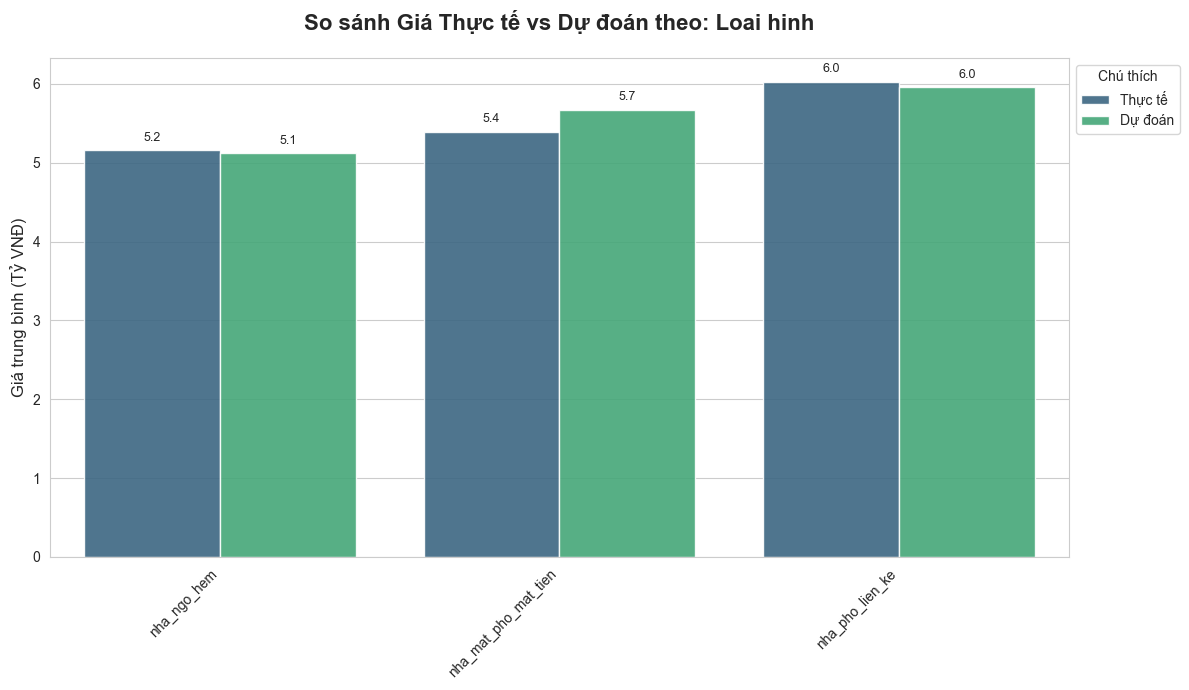

In [179]:
df_histplot_1 = df_pr1_2
groupby_features = ["loai_hinh"]
visualize_bar_price(df_histplot_1, groupby_features)

**Theo quận huyện**

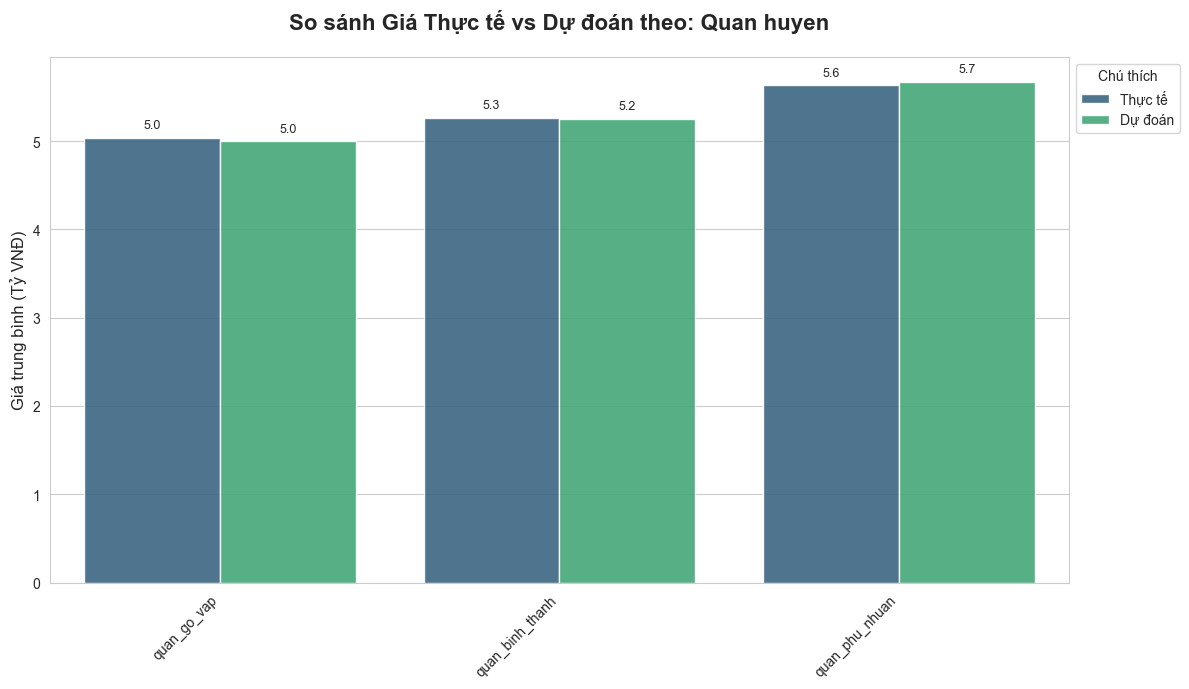

In [180]:
groupby_features = ["quan_huyen"]
visualize_bar_price(df_histplot_1, groupby_features)

**Theo quận huyện - loại hình**

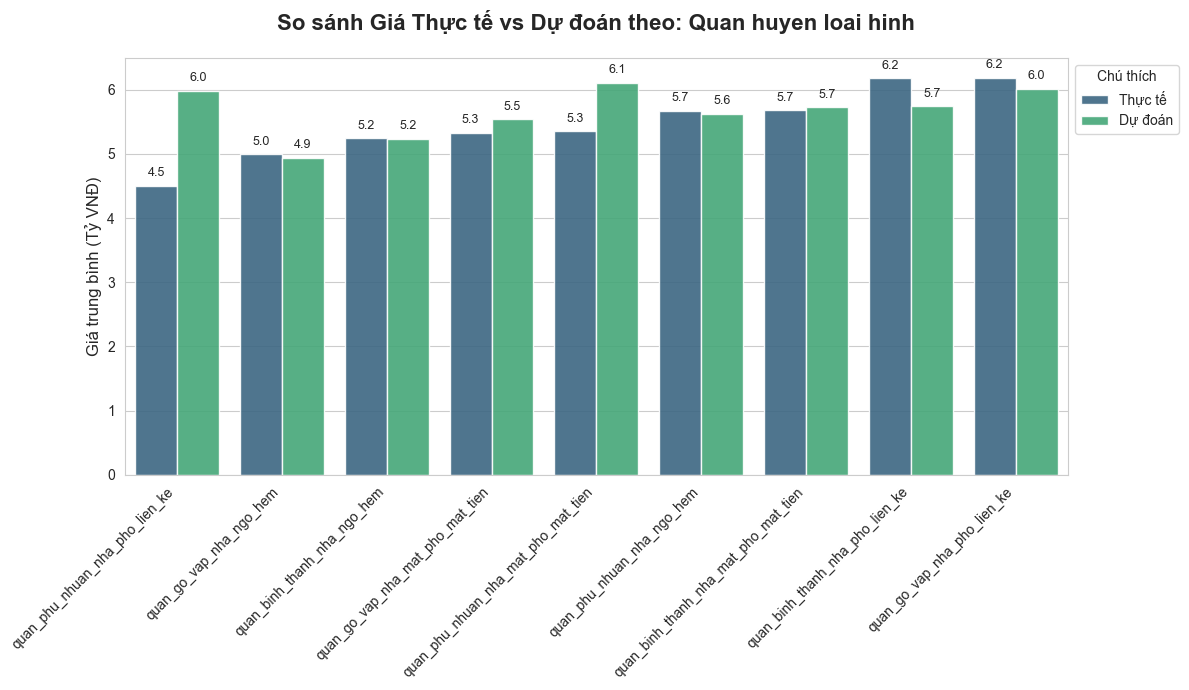

In [181]:
groupby_features = ["quan_huyen_loai_hinh"]
visualize_bar_price(df_histplot_1, groupby_features)

**Theo tổng số tầng**

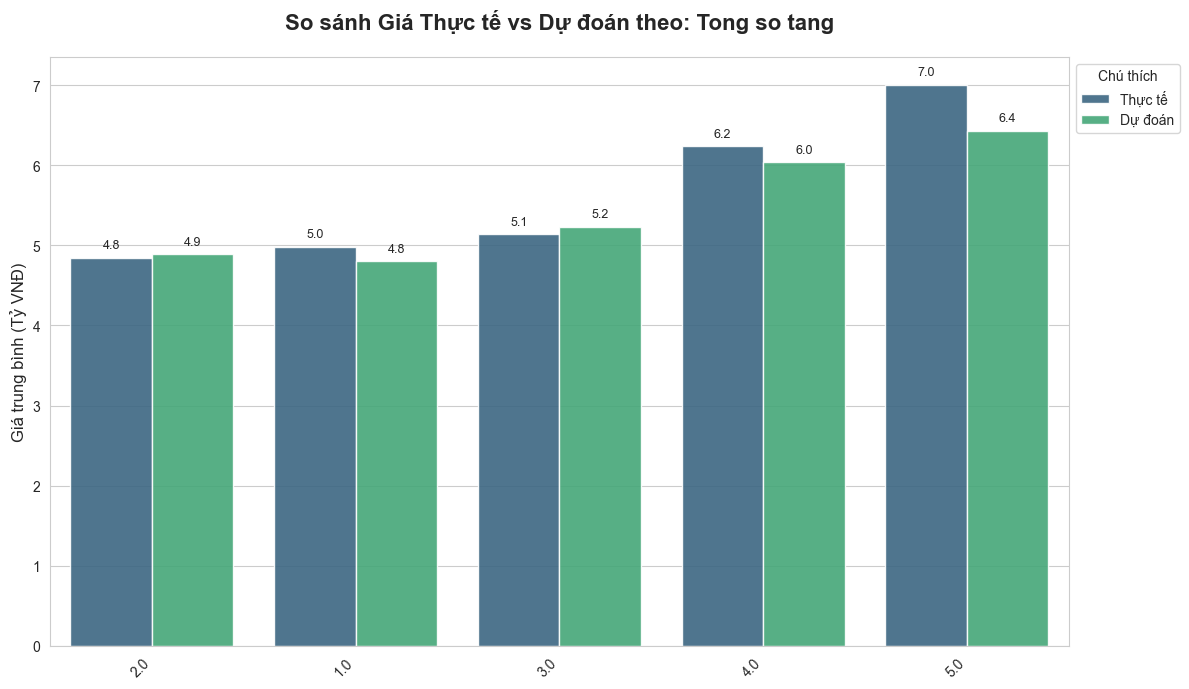

In [182]:
groupby_features = ["tong_so_tang"]
visualize_bar_price(df_histplot_1, groupby_features)

## Phương Pháp 1: Residual-Z

### Ý tưởng
Dùng XGBoost dự đoán giá → tính **sai số** giữa giá thực và giá dự đoán → chuẩn hóa thành Z-score.  
Căn nhà có **|Z| lớn** nghĩa là giá thực lệch xa so với mức mà thị trường "kỳ vọng" → bất thường.

### Công thức
$$e = y_{\text{thực tế}} - y_{\text{dự đoán}}$$
$$Z_{resid} = \frac{e - \bar{e}}{\sigma_e}$$
$$S_{resid} = \frac{|Z| - |Z|_{min}}{|Z|_{max} - |Z|_{min}} \quad \text{(clip tại |Z|=3)}$$

- Z > 0 → giá thực **cao hơn** dự đoán (có thể quá đắt)  
- Z < 0 → giá thực **thấp hơn** dự đoán (có thể quá rẻ)  
- |Z| > 2 → bất thường | |Z| > 3 → rất bất thường

#### **Khai báo hàm**

In [183]:
def detect_real_estate_anomalies_by_residual_z(df, groupby_features):
    # Tính sai số (residual)
    df['residual'] = df['gia_ban'] - df['final_prediction']

    # Tính Trung bình và Độ lệch chuẩn của residual theo từng nhóm (Window function)
    # transform() giúp giữ nguyên số lượng dòng của dataframe gốc
    df['avg_res'] = df.groupby(groupby_features)['residual'].transform('mean')
    df['std_res'] = df.groupby(groupby_features)['residual'].transform('std')

    # Tính Z-score của sai số
    # Thêm 1 lượng cực nhỏ (1e-9) vào mẫu số để tránh lỗi chia cho 0 nếu std = 0
    df['residual_z'] = (df['residual'] - df['avg_res']) / (df['std_res'] + 1e-9)

    # Đánh dấu vi phạm (Outliers) nếu |Z| > 3
    df['violate_residual_z'] = np.where(df['residual_z'].abs() > 3, 1, 0)

    return df

In [184]:
def composite_scores(df, groupby_features, methods,
                     threshold_pr_min=None, threshold_pr_max=None,
                     threshold_po_min=None, threshold_po_max=None,
                     feature_cols=None, isf_contamination=0.05):

    df_anomalies = df.copy()

    # Chạy các phương pháp phát hiện dựa trên danh sách keys của methods
    for method in methods.keys():
        if method == "residual_z":
            df_anomalies = detect_real_estate_anomalies_by_residual_z(df_anomalies, groupby_features)
        elif method == "min_max":
            df_anomalies = detect_real_estate_anomalies_by_min_max(df_anomalies, groupby_features, threshold_pr_min, threshold_pr_max)
        elif method == "outside_conf":
            df_anomalies = detect_real_estate_anomalies_by_outside_conf(df_anomalies, groupby_features, threshold_po_min, threshold_po_max)
        elif method == "isolation_forest":
            df_anomalies = detect_real_estate_anomalies_by_isolation_forest(df_anomalies, groupby_features, feature_cols, isf_contamination)

    # Tính điểm tổng hợp (Weighted Score)
    # Khởi tạo cột điểm bằng 0
    df_anomalies['raw_anomaly_score'] = 0.0

    for method, weights in methods.items():
        for col_name, weight in weights.items():
            if col_name in df_anomalies.columns:
                df_anomalies['raw_anomaly_score'] += df_anomalies[col_name] * weight

    # Chuẩn hóa về thang điểm 100
    max_val = df_anomalies['raw_anomaly_score'].max()

    if max_val == 0 or pd.isna(max_val):
        df_anomalies['final_anomaly_score'] = 0.0
    else:
        df_anomalies['final_anomaly_score'] = (df_anomalies['raw_anomaly_score'] / max_val) * 100

    return df_anomalies

In [185]:
def extract_anomalies(df, threshold_outlier_percent):
    # Tạo bản sao để không ảnh hưởng đến DataFrame gốc
    df_anomalies = df.copy()

    # Tính giá trị ngưỡng (ceiling_score)
    # Tương đương với approxQuantile trong Spark
    # threshold_outlier_percent (ví dụ: 1 - 0.05 = 0.95)
    ceiling_score = df_anomalies["final_anomaly_score"].quantile(1 - threshold_outlier_percent)

    # Lọc các dòng có score >= ngưỡng và sắp xếp giảm dần
    list_anomalies = df_anomalies[df_anomalies["final_anomaly_score"] >= ceiling_score] \
                        .sort_values(by="final_anomaly_score", ascending=False)

    return list_anomalies

In [186]:
def report_anomalies(df, groupby_features, methods, methods_features, methods_flags,
                     threshold_outlier_percent, threshold_pr_min=None,
                     threshold_pr_max=None, threshold_po_min=None,
                     threshold_po_max=None, feature_cols=None, isf_contamination=None):

    # Tính toán điểm tổng hợp
    df_anomalies = composite_scores(df, groupby_features, methods,
                                   threshold_pr_min, threshold_pr_max,
                                   threshold_po_min, threshold_po_max,
                                   feature_cols, isf_contamination)

    # Trích xuất anomalies theo percentile
    list_anomalies = extract_anomalies(df_anomalies, threshold_outlier_percent)

    # Tạo điều kiện lọc (Combined Condition): Chỉ lấy những dòng có ít nhất 1 flag vi phạm
    # Trong Pandas, dùng (df[flags] == 1).any(axis=1) thay cho reduce(|)
    combined_condition = (list_anomalies[methods_flags] == 1).any(axis=1)
    list_anomalies = list_anomalies[combined_condition]

    # Xác định các cột cần hiển thị
    # Sử dụng list để gom nhóm các cột tránh trùng lặp
    base_columns = ["gia_ban", "final_prediction"]
    info_columns = ["dien_tich_dat", "dien_tich_su_dung", "chieu_ngang", "tong_so_tang",
                    "so_phong_ngu", "giay_to_phap_ly", "tinh_trang_noi_that", "dac_diem",
                    "dia_chi_cu", "dia_chi_moi"]

    selected_columns = (base_columns +
                        (methods_features if methods_features else []) +
                        methods_flags +
                        ["final_anomaly_score"] +
                        groupby_features +
                        info_columns)

    # Lọc các cột hiện có trong DataFrame để tránh lỗi KeyNotFound
    selected_columns = [c for c in selected_columns if c in list_anomalies.columns]

    # Sắp xếp (OrderBy)
    orderby_features = ["final_anomaly_score"] + groupby_features + (methods_features if methods_features else [])
    # Sắp xếp giảm dần cho toàn bộ các cột tiêu chí
    list_anomalies = list_anomalies[selected_columns].sort_values(
        by=orderby_features,
        ascending=False
    )

    # Hiển thị kết quả
    print(f"Số lượng nhà bất thường phát hiện: {len(list_anomalies)}")
    # Hiển thị 20 dòng đầu tiên tương tự .show() của Spark
    if not list_anomalies.empty:
        print(list_anomalies.head(20).to_string())

    return df_anomalies, list_anomalies

**Biểu đồ Scatter: Giá thực tế vs Giá dự đoán (Highlight Outliers)**

Biểu đồ này giúp ta thấy rõ những căn nhà có sai số cực lớn (nằm xa đường chéo)

In [187]:
def scatter_highlight_outliers(df_anomalies, list_anomalies, sample_frac=0.1):
    """
    Vẽ biểu đồ Scatter Plot để trực quan hóa dữ liệu bất thường trên nền dữ liệu mẫu.
    """
    # Lấy mẫu dữ liệu nền (Normal Data) để tránh quá tải biểu đồ nếu dữ liệu lớn
    # Nếu dữ liệu nhỏ, có thể đặt sample_frac=1.0
    pdf_sample = df_anomalies.sample(frac=sample_frac, random_state=42)

    # Dữ liệu bất thường đã là Pandas nên không cần chuyển đổi
    pdf_anomalies = list_anomalies

    plt.figure(figsize=(12, 8))

    # Vẽ dữ liệu bình thường (Màu xám, độ trong suốt thấp)
    sns.scatterplot(
        data=pdf_sample,
        x='final_prediction',
        y='gia_ban',
        alpha=0.3,
        label='Dữ liệu mẫu (Normal)',
        color='gray'
    )

    # Highlight dữ liệu bất thường (Màu đỏ, kích thước lớn hơn)
    sns.scatterplot(
        data=pdf_anomalies,
        x='final_prediction',
        y='gia_ban',
        color='red',
        label='Bất thường (Anomalies)',
        s=100,
        edgecolor='black'
    )

    # Vẽ đường chéo lý tưởng (Y = X)
    # Tìm giá trị lớn nhất của cả 2 trục để vẽ đường cân bằng
    all_max = max(
        pdf_sample[['gia_ban', 'final_prediction']].max().max(),
        pdf_anomalies[['gia_ban', 'final_prediction']].max().max()
    )
    plt.plot([0, all_max], [0, all_max], '--', color='blue', alpha=0.5, label='Đường lý tưởng')

    # Định dạng biểu đồ
    plt.title("Phát hiện bất thường: Giá thực tế vs Giá dự đoán", fontsize=15)
    plt.xlabel("Giá dự đoán (Model Prediction)", fontsize=12)
    plt.ylabel("Giá thực tế (Actual Price)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

In [188]:
def visualize_anomalies_by_selected_features(df, methods_flags):
    """
    df: Pandas DataFrame
    methods_flags: List các tên cột chứa cờ bất thường (ví dụ: ['is_anomaly_iforest'])
    """
    # 1. Lấy các cột cần thiết (Lọc trực tiếp trên Pandas DataFrame)
    needed_cols = ["quan_huyen_loai_hinh", "giay_to_phap_ly", "gia_ban"] + methods_flags
    pdf = df[needed_cols].copy()

    # 2. Xác định điểm bất thường tổng hợp (nếu một trong các phương pháp báo 1 thì coi là 1)
    pdf['is_any_anomaly'] = pdf[methods_flags].max(axis=1)

    # Sắp xếp để vẽ điểm xanh (bình thường) trước, điểm đỏ (bất thường) đè lên trên cho dễ thấy
    pdf_sorted = pdf.sort_values(by='is_any_anomaly', ascending=True)

    # 3. Định nghĩa bảng màu và kích thước điểm
    # 1 (Bất thường) -> Đỏ (#D32F2F), 0 (Bình thường) -> Xanh (#4CAF50)
    colors = pdf_sorted['is_any_anomaly'].map({1: '#D32F2F', 0: '#4CAF50'})
    sizes = pdf_sorted['is_any_anomaly'].map({1: 30, 0: 15})

    # 4. Khởi tạo biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Phân tích điểm bất thường trong dữ liệu Bất động sản', fontsize=14, fontweight='bold')

    # Biểu đồ 1: Quận huyện/Loại hình vs Giá
    axes[0].scatter(
        pdf_sorted['quan_huyen_loai_hinh'],
        pdf_sorted['gia_ban'],
        c=colors,
        s=sizes,
        alpha=0.6
    )
    axes[0].set_title('Quận huyện & Loại hình vs Giá\n(Đỏ = Bất thường)')
    axes[0].set_ylabel('Giá bán (Tỷ đồng)')
    axes[0].tick_params(axis='x', rotation=45)

    # Biểu đồ 2: Pháp lý vs Giá
    axes[1].scatter(
        pdf_sorted['giay_to_phap_ly'],
        pdf_sorted['gia_ban'],
        c=colors,
        s=sizes,
        alpha=0.6
    )
    axes[1].set_title('Tình trạng pháp lý vs Giá\n(Đỏ = Bất thường)')
    axes[1].set_ylabel('Giá bán (Tỷ đồng)')
    axes[1].tick_params(axis='x', rotation=45)

    # Căn chỉnh nhãn cho đẹp
    for ax in axes:
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

#### **Thực thi Residual-z**

### Residual-z chuẩn hóa sai số theo 'loai_hinh' vì mức độ biến động giá khác nhau rõ rệt giữa các loại hình

In [189]:
threshold_outlier_percent = 0.05  # 5%
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "residual_z": {
        "violate_residual_z": 100 # Trọng số cho điểm số tổng hợp
    }
}
methods_features = ["residual"]
methods_flags = ["violate_residual_z"]

df_anomalies, list_anomalies = report_anomalies(df_pr1_2, groupby_features, methods, methods_features, methods_flags, threshold_outlier_percent)


Số lượng nhà bất thường phát hiện: 6
     gia_ban  final_prediction  residual  violate_residual_z  final_anomaly_score       quan_huyen             loai_hinh  dien_tich_dat  dien_tich_su_dung  chieu_ngang  tong_so_tang  so_phong_ngu giay_to_phap_ly tinh_trang_noi_that         dac_diem                 dia_chi_cu            dia_chi_moi
152     7.50          4.280987  3.219013                   1                100.0      quan_go_vap           nha_ngo_hem           39.0         139.000000     4.239130           3.0           3.0        da_co_so       chua_xac_dinh      nha_top_hau      phuong_12_quan_go_vap      phuong_an_hoi_tay
699     7.68          5.087090  2.592910                   1                100.0      quan_go_vap           nha_ngo_hem           33.0         124.587578     4.125000           4.0           4.0        da_co_so       chua_xac_dinh  hien_trang_khac      phuong_10_quan_go_vap          phuong_go_vap
660     3.50          6.252948 -2.752948                   1      

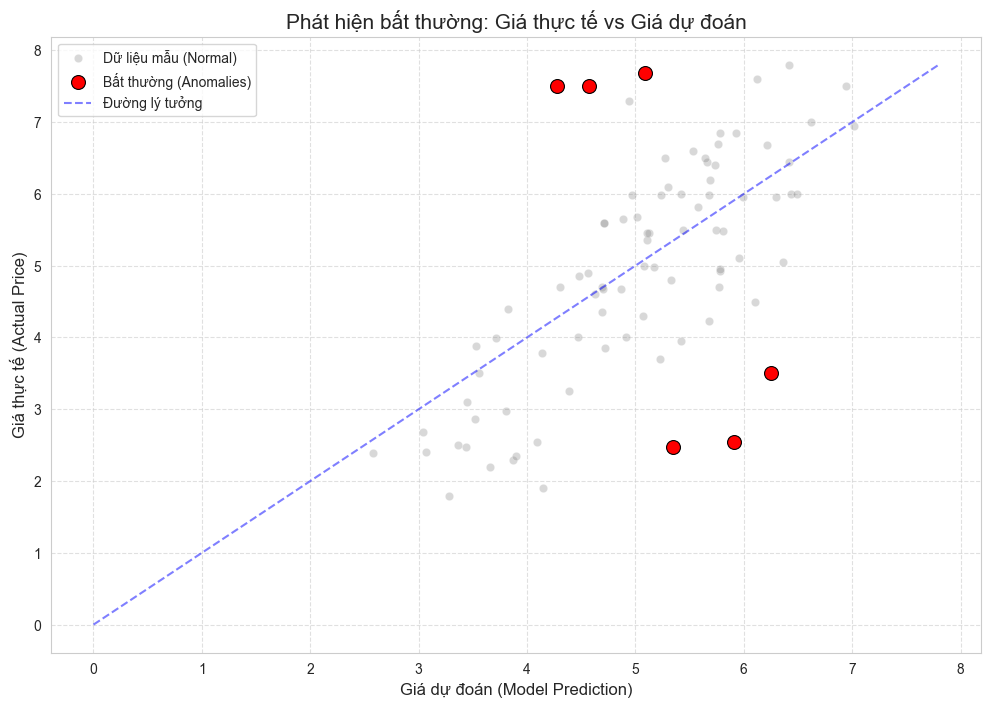

In [190]:
scatter_highlight_outliers(df_anomalies, list_anomalies)

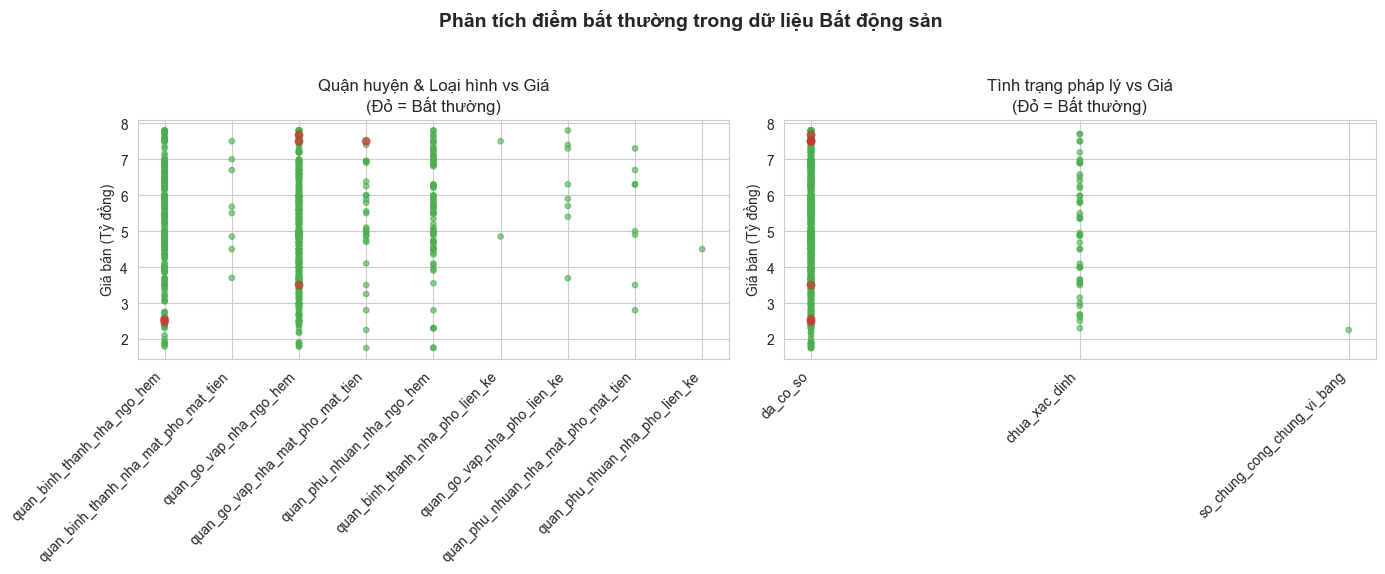

In [191]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

**Biểu đồ phân phối Residual-Z**

- Giúp quan sát ngưỡng cắt (threshold) mà tại đó một bản ghi bị coi là bất thường
- Đa số dữ liệu sẽ tập trung quanh vị trí 0. Những điểm nằm ngoài khoảng $[-3, 3]$ là những biến động cực đoan (outliers) về mặt thống kê.

In [192]:
def histplot_residual_z(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[['residual_z']], kde=True, color='skyblue')

    # Vẽ đường ngưỡng (ví dụ z > 3 hoặc z < -3)
    plt.axvline(x=3, color='red', linestyle='--', label='Upper Threshold (3z)')
    plt.axvline(x=-3, color='red', linestyle='--', label='Lower Threshold (-3z)')

    plt.title("Phân phối của Residual-Z (Sai số chuẩn hóa)")
    plt.legend()
    plt.show()

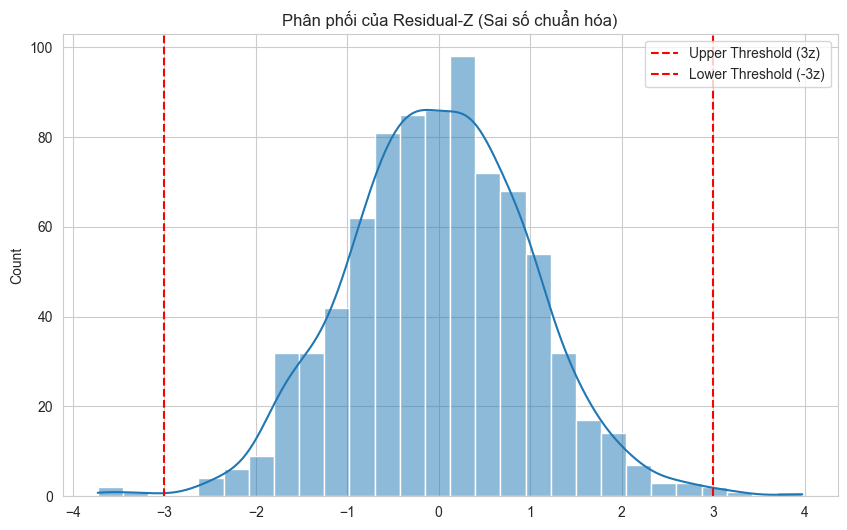

In [193]:
histplot_residual_z(df_anomalies)

### Phương Pháp 2: Vi Phạm Min/Max

### Ý tưởng
Thiết lập **khung giá sàn và giá trần** cho từng nhóm (quận + loại hình) dựa trên phân phối thực tế và giá lịch sử.  
Căn nhà có giá vượt ra ngoài ngưỡng → nghi ngờ **lỗi nhập liệu** hoặc **gian lận giá**.

### Công thức
$$Price_{min} = \mu - 3\sigma \quad , \quad Price_{max} = \mu + 3\sigma$$
$$S_{min\_max} = \begin{cases} 1 & \text{nếu } Price < Price_{min} \text{ hoặc } Price > Price_{max} \\ 0 & \text{nếu nằm trong khoảng an toàn} \end{cases}$$

Nhóm theo **(quận/ huyện + loại hình)** để đảm bảo so sánh công bằng — nhà mặt tiền Phú Nhuận và nhà hẻm Gò Vấp có mặt bằng giá rất khác nhau.

### Ưu và nhược điểm
**Ưu điểm:**

Công bằng: Không dùng chung một ngưỡng cho mọi loại nhà. Biệt thự 5 tỷ là "rẻ bất thường" nhưng căn hộ 5 tỷ là "bình thường".

Hiệu quả: Loại bỏ được các lỗi nhập liệu (nhập thiếu số 0 hoặc thừa số 0).

**Nhược điểm:**

Dễ mất dữ liệu hiếm: Những căn nhà siêu sang (Penthouse) hoặc nhà nát thực sự có thể bị đánh nhầm là bất thường nếu chúng nằm ở top 1% về giá.

In [194]:
def detect_real_estate_anomalies_by_min_max(df, groupby_features, threshold_pr_min, threshold_pr_max):
    # Tạo bản sao để tránh lỗi SettingWithCopyWarning
    df = df.copy()

    # Tính toán P1 và P99 theo phân khúc bằng transform
    # transform giúp giữ nguyên số lượng dòng của df gốc để gán trực tiếp
    df['price_min'] = df.groupby(groupby_features)['gia_ban'].transform(lambda x: x.quantile(threshold_pr_min))
    df['price_max'] = df.groupby(groupby_features)['gia_ban'].transform(lambda x: x.quantile(threshold_pr_max))

    # Tính toán các cột vi phạm (violate)
    # Trong Pandas, phép so sánh trả về True/False, ta dùng .astype(int) để chuyển về 1/0
    df['violate_min'] = (df['gia_ban'] < df['price_min']).astype(int)
    df['violate_max'] = (df['gia_ban'] > df['price_max']).astype(int)

    # Vi phạm chung (kết hợp min hoặc max)
    df['violate_min_max'] = ((df['violate_min'] == 1) | (df['violate_max'] == 1)).astype(int)

    return df

### **Thực thi Min-Max**

In [195]:
threshold_outlier_percent = 0.05
threshold_pr_min = 0.01
threshold_pr_max = 0.99
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "min_max": {
        "violate_min_max": 100
    }
}
methods_features = ["violate_min", "violate_max", "price_min", "price_max"]
methods_flags = ["violate_min_max"]

df_anomalies, list_anomalies = report_anomalies(df_pr1_2, groupby_features, methods, methods_features, methods_flags, threshold_outlier_percent, \
                 threshold_pr_min=threshold_pr_min, threshold_pr_max=threshold_pr_max)


Số lượng nhà bất thường phát hiện: 19
     gia_ban  final_prediction  violate_min  violate_max  price_min  price_max  violate_min_max  final_anomaly_score       quan_huyen             loai_hinh  dien_tich_dat  dien_tich_su_dung  chieu_ngang  tong_so_tang  so_phong_ngu giay_to_phap_ly tinh_trang_noi_that         dac_diem                 dia_chi_cu            dia_chi_moi
800     1.75          4.020058            1            0     1.7586     7.8000                1                100.0   quan_phu_nhuan           nha_ngo_hem          10.00          33.009880     1.843909           3.0           2.0        da_co_so       chua_xac_dinh  hien_trang_khac   phuong_13_quan_phu_nhuan       phuong_phu_nhuan
774     2.80          4.471481            1            0     2.8490     7.2580                1                100.0   quan_phu_nhuan  nha_mat_pho_mat_tien          12.00          37.461573     4.000000           3.0           2.0        da_co_so   hoan_thien_co_ban  hien_trang_khac    phuong_

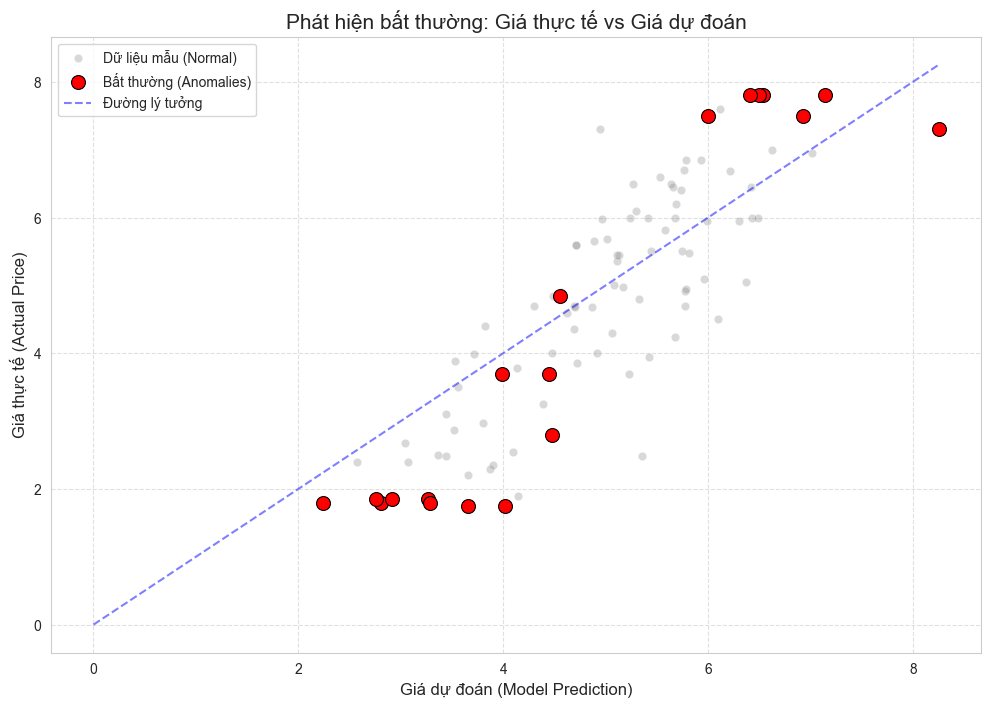

In [196]:
scatter_highlight_outliers(df_anomalies, list_anomalies)

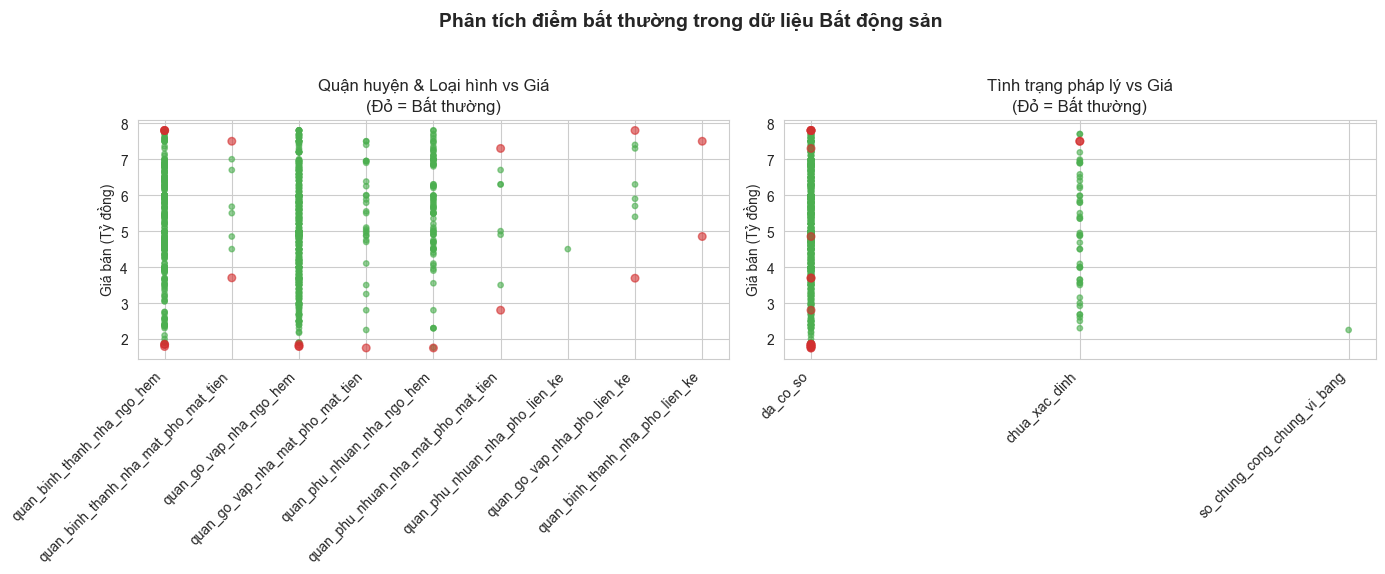

In [197]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

### Phương Pháp 3: Ngoài Khoảng P10-P90

### Ý tưởng
Xác định **"vùng giá phổ biến"** của thị trường — 80% giao dịch nằm trong [P10, P90].  
Căn nhà nằm ngoài khoảng này được gắn cờ kiểm tra, không bị ảnh hưởng bởi các giá trị cực đoan.

### Công thức
$$\text{Khoảng tin cậy} = [P_{10}, P_{90}]$$
$$d = \begin{cases} P_{10} - Price & \text{nếu } Price < P_{10} \\ Price - P_{90} & \text{nếu } Price > P_{90} \\ 0 & \text{nếu nằm trong khoảng} \end{cases}$$
$$S_{percentile} = \frac{d - d_{min}}{d_{max} - d_{min}}$$

**Ưu điểm so với Min/Max:** Không bị ảnh hưởng bởi outlier cực đoan khi tính ngưỡng.

In [198]:
def detect_real_estate_anomalies_by_outside_conf(df, groupby_features, threshold_po_min, threshold_po_max):
    # Tạo bản sao để tránh SettingWithCopyWarning
    df = df.copy()

    # Xác định tên cột động dựa trên tham số (%)
    col_min = f"P{int(threshold_po_min * 100)}"
    col_max = f"P{int(threshold_po_max * 100)}"

    # Tính toán percentile theo từng nhóm và map ngược lại vào df gốc
    # transform('quantile') sẽ trả về một Series có cùng độ dài với df
    df[col_min] = df.groupby(groupby_features)['gia_ban'].transform(lambda x: x.quantile(threshold_po_min))
    df[col_max] = df.groupby(groupby_features)['gia_ban'].transform(lambda x: x.quantile(threshold_po_max))

    # Gắn nhãn các vi phạm (Sử dụng vectorization của numpy/pandas để đạt tốc độ cao)
    df['outside_conf_min'] = (df['gia_ban'] < df[col_min]).astype(int)
    df['outside_conf_max'] = (df['gia_ban'] > df[col_max]).astype(int)

    # 4. Tạo flag tổng hợp (1 nếu vi phạm ít nhất 1 đầu)
    df['outside_conf_flag'] = ((df['outside_conf_min'] == 1) | (df['outside_conf_max'] == 1)).astype(int)

    return df

### **Thực thi ngoài khoảng tin cậy**

### Chọn ngoài khoảng tin cậy [P10, P90]

In [199]:
threshold_outlier_percent = 0.05    # 5%
threshold_po_min = 0.1              # P10
threshold_po_max = 0.9              # P90
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "outside_conf": {
        "outside_conf_flag": 100
    }
}
methods_features = ["outside_conf_min", "outside_conf_max"]
methods_flags = ["outside_conf_flag"]

# Using explicit keyword arguments to avoid positional mapping errors with optional parameters
df_anomalies, list_anomalies = report_anomalies(
                                                df=df_pr1_2,
                                                groupby_features=groupby_features,
                                                methods=methods,
                                                methods_features=methods_features,
                                                methods_flags=methods_flags,
                                                threshold_outlier_percent=threshold_outlier_percent,
                                                threshold_po_min=threshold_po_min,
                                                threshold_po_max=threshold_po_max
                                            )

Số lượng nhà bất thường phát hiện: 162
     gia_ban  final_prediction  outside_conf_min  outside_conf_max  outside_conf_flag  final_anomaly_score      quan_huyen             loai_hinh  dien_tich_dat  dien_tich_su_dung  chieu_ngang  tong_so_tang  so_phong_ngu giay_to_phap_ly tinh_trang_noi_that         dac_diem                dia_chi_cu       dia_chi_moi
776     2.30          3.557482                 1                 0                  1                100.0  quan_phu_nhuan           nha_ngo_hem           10.0          10.000000     1.843909           1.0           1.0        da_co_so       chua_xac_dinh       hem_xe_hoi   phuong_9_quan_phu_nhuan  phuong_duc_nhuan
789     2.30          4.247498                 1                 0                  1                100.0  quan_phu_nhuan           nha_ngo_hem           15.0          44.139113     3.000000           3.0           2.0        da_co_so     noi_that_day_du       hem_xe_hoi   phuong_7_quan_phu_nhuan   phuong_cau_kieu
800     1.

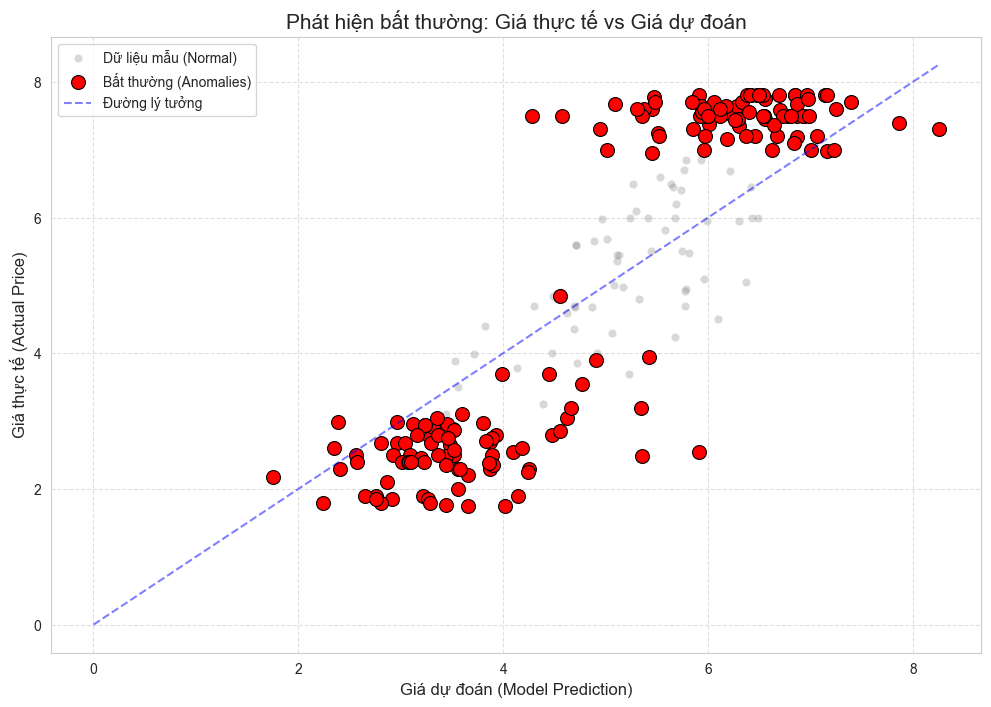

In [200]:
scatter_highlight_outliers(df_anomalies, list_anomalies)

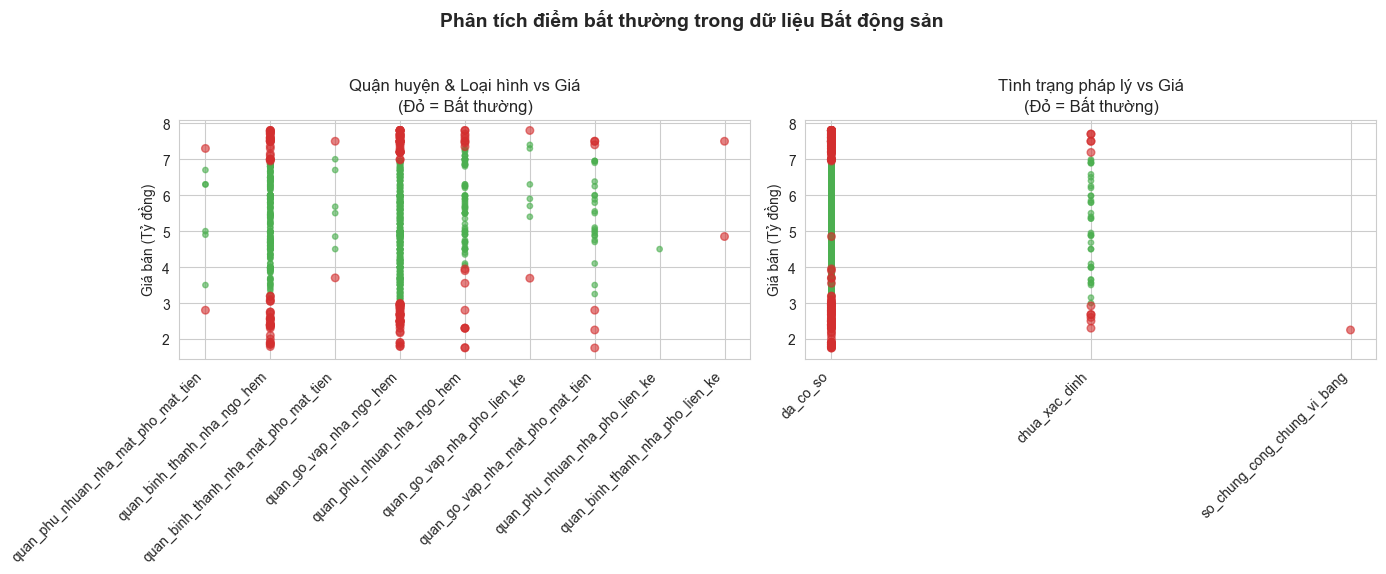

In [201]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

### Phương Pháp 4: Isolation Forest (Unsupervised ML)

### Ý tưởng
Thuật toán học máy **không giám sát** — phát hiện bất thường **đa chiều**, ví dụ nhà 20m² mà có 10 phòng ngủ.  
Các điểm bất thường dễ bị **"cô lập"** bằng ít bước phân chia cây hơn so với điểm bình thường.

Score càng thấp/âm → càng bất thường.

In [202]:
def detect_real_estate_anomalies_by_isolation_forest(df, groupby_features, feature_cols, isf_contamination):
    # Tạo bản sao để tránh thay đổi dữ liệu gốc
    df = df.copy()

    def iforest_group_logic(pdf):
        # Kiểm tra điều kiện tối thiểu 10 dòng như logic Spark của bạn
        if len(pdf) >= 10:
            # Xử lý dữ liệu thiếu cho các feature
            X = pdf[feature_cols].fillna(0)

            # Khởi tạo và huấn luyện mô hình
            model = IsolationForest(contamination=isf_contamination, random_state=42)
            model.fit(X)

            # decision_function: Càng thấp (càng âm) càng bất thường
            pdf['iforest_score'] = model.decision_function(X)

            # predict: Trả về -1 (outlier) hoặc 1 (inlier)
            preds = model.predict(X)
            pdf['is_anomaly_iforest'] = (preds == -1).astype(int)
        else:
            # Nếu nhóm quá ít dữ liệu, gán mặc định là không bất thường
            pdf['iforest_score'] = 0.0
            pdf['is_anomaly_iforest'] = 0

        return pdf

    # Áp dụng hàm xử lý cho từng nhóm (theo quận/huyện hoặc loại hình)
    result_df = df.groupby(groupby_features, group_keys=False).apply(iforest_group_logic)

    # Sắp xếp: score thấp nhất (bất thường nhất) lên đầu
    result_df = result_df.sort_values(by="iforest_score", ascending=True)

    return result_df

In [203]:
threshold_percent = 0.05
isf_contamination = 0.05
feature_cols = ["dien_tich_su_dung", "gia_ban", "final_prediction"]
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "isolation_forest": {
        "is_anomaly_iforest": 100 # Trọng số cho điểm số tổng hợp
    }
}
methods_features = ["iforest_score"]
methods_flags = ["is_anomaly_iforest"]

df_anomalies, list_anomalies = report_anomalies(df_pr1_2, groupby_features, methods, methods_features, methods_flags, threshold_percent, \
                                                feature_cols=feature_cols, isf_contamination=isf_contamination)


Số lượng nhà bất thường phát hiện: 41
     gia_ban  final_prediction  iforest_score  is_anomaly_iforest  final_anomaly_score      quan_huyen    loai_hinh  dien_tich_dat  dien_tich_su_dung  chieu_ngang  tong_so_tang  so_phong_ngu giay_to_phap_ly tinh_trang_noi_that         dac_diem                dia_chi_cu           dia_chi_moi
800     1.75          4.020058      -0.001954                   1                100.0  quan_phu_nhuan  nha_ngo_hem           10.0          33.009880     1.843909           3.0           2.0        da_co_so       chua_xac_dinh  hien_trang_khac  phuong_13_quan_phu_nhuan      phuong_phu_nhuan
408     7.30          8.362255      -0.034906                   1                100.0  quan_phu_nhuan  nha_ngo_hem           80.3         165.000000     3.734884           2.0           6.0        da_co_so     noi_that_day_du          nha_nat  phuong_13_quan_phu_nhuan      phuong_phu_nhuan
391     7.00          8.044131      -0.045970                   1                100.0

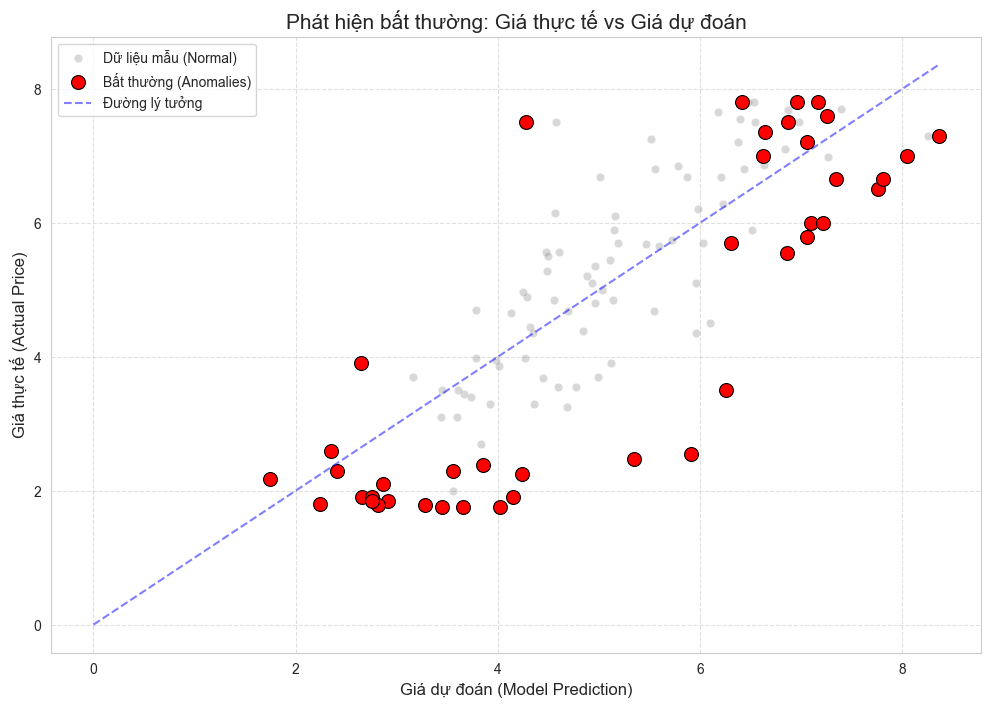

In [204]:
scatter_highlight_outliers(df_anomalies, list_anomalies)

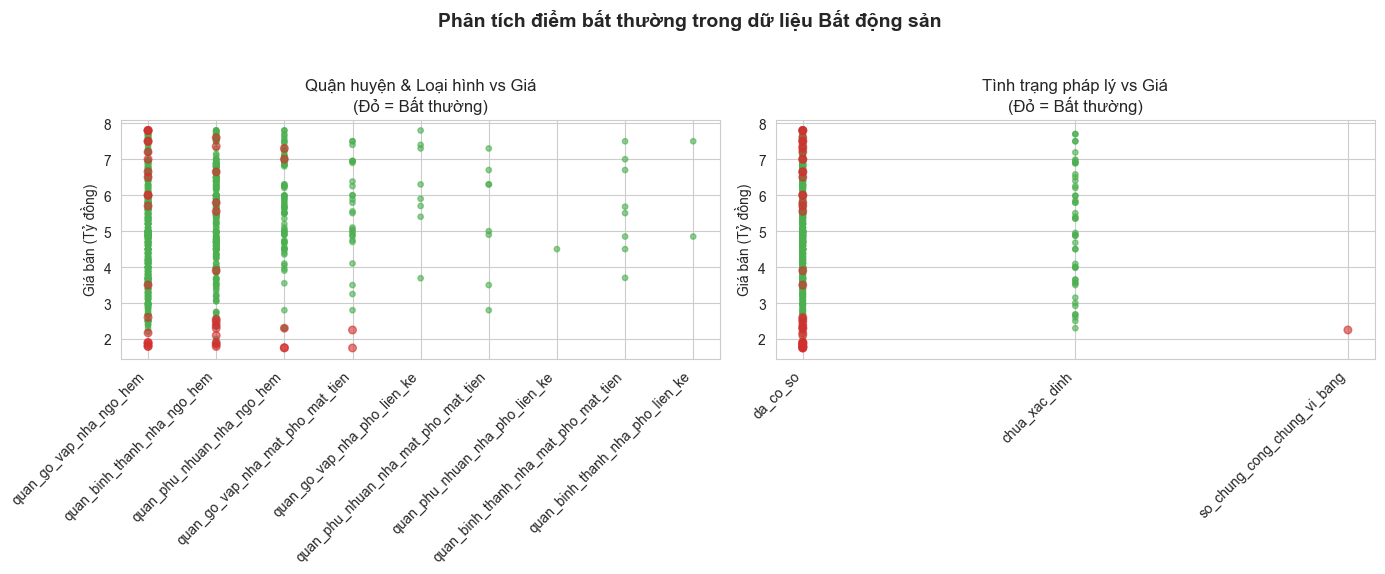

In [205]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

**Tổng hợp**

### Trọng số: Residual-z (30%), Vi phạm Min/Max (25%), Ngoài khoảng tin cậy (15%), Isolation Forest (30%)

In [206]:
threshold_outlier_percent = 0.05    # 5%  - Lấy 5% top bất thường nhất
threshold_pr_min = 0.01             # P1  - Min-Max
threshold_pr_max = 0.99             # P99 - Min-Max
threshold_po_min = 0.1              # P10 - Ngoài khoảng tin cậy
threshold_po_max = 0.9              # P90 - Ngoài khoảng tin cậy
isf_contamination = 0.05
feature_cols = ["dien_tich_su_dung", "gia_ban", "final_prediction"]
groupby_features = ["quan_huyen", "loai_hinh"]
methods = {
    "residual_z": {
        "violate_residual_z": 30
    },
    "min_max": {
        "violate_min_max": 25
    },
    "outside_conf": {
        "outside_conf_flag": 15
    },
    "isolation_forest": {
        "is_anomaly_iforest": 30
    }
}
methods_features = ["residual", "violate_min", "violate_max", "price_min", "price_max", "outside_conf_min", "outside_conf_max", "iforest_score"]
methods_flags = ["violate_residual_z", "violate_min_max", "outside_conf_flag", "is_anomaly_iforest"]

df_anomalies, list_anomalies = report_anomalies(df_pr1_2, groupby_features, methods, methods_features, methods_flags=methods_flags, \
                                                threshold_outlier_percent=threshold_outlier_percent, \
                                                threshold_pr_min=threshold_pr_min, threshold_pr_max=threshold_pr_max, \
                                                threshold_po_min=threshold_po_min, threshold_po_max=threshold_po_max, \
                                                feature_cols=feature_cols, isf_contamination=isf_contamination)

Số lượng nhà bất thường phát hiện: 44
     gia_ban  final_prediction  residual  violate_min  violate_max  price_min  price_max  outside_conf_min  outside_conf_max  iforest_score  violate_residual_z  violate_min_max  outside_conf_flag  is_anomaly_iforest  final_anomaly_score       quan_huyen             loai_hinh  dien_tich_dat  dien_tich_su_dung  chieu_ngang  tong_so_tang  so_phong_ngu giay_to_phap_ly tinh_trang_noi_that         dac_diem                 dia_chi_cu            dia_chi_moi
152     7.50          4.280987  3.219013            0            0     1.9000     7.8000                 0                 1      -0.035166                   1                0                  1                   1           100.000000      quan_go_vap           nha_ngo_hem           39.0         139.000000     4.239130           3.0           3.0        da_co_so       chua_xac_dinh      nha_top_hau      phuong_12_quan_go_vap      phuong_an_hoi_tay
78      2.48          5.351223 -2.871223            0 

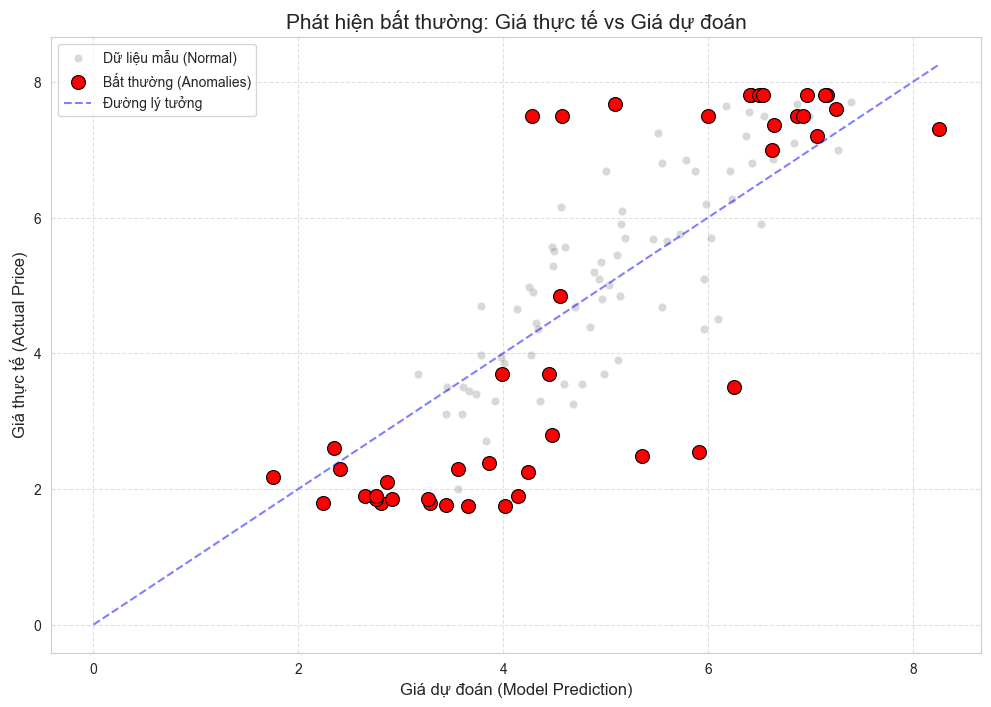

In [207]:
scatter_highlight_outliers(df_anomalies, list_anomalies)

**Giải thích biểu đồ**
- **Vùng giá quá rẻ (Dưới đường chéo)**: Các chấm đỏ nằm xa phía dưới đường nét đứt màu xanh là những căn nhà có giá rao bán thấp hơn rất nhiều so với giá trị thực mà mô hình tính toán được. Đây có thể là những cơ hội đầu tư hoặc lỗi nhập liệu.
- **Vùng giá quá đắt (Trên đường chéo)**: Các chấm đỏ nằm vọt lên trên là những căn nhà "ngáo giá" hoặc có những đặc điểm cực kỳ cao cấp mà các biến số hiện tại (diện tích, số phòng) chưa phản ánh hết.


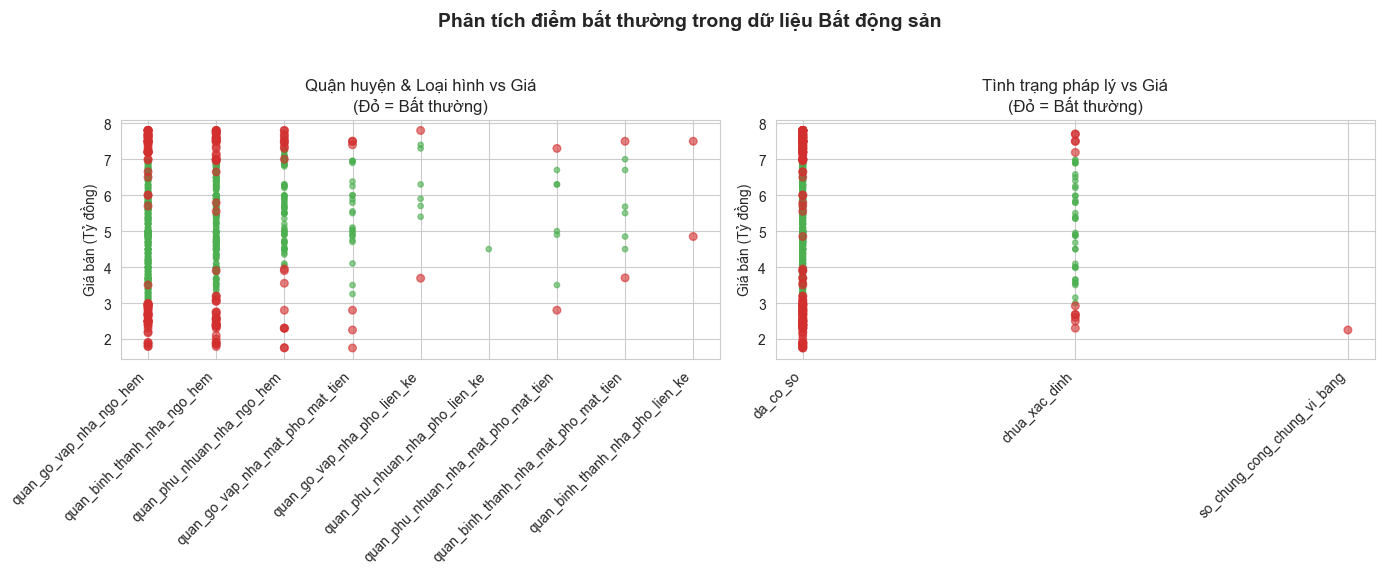

In [208]:
visualize_anomalies_by_selected_features(df_anomalies, methods_flags)

**Quận Gò Vấp** có nhiều dữ liệu bất thường nhất, trải dài ở nhiều phân khúc, suy ra:
- Mặt chủ quan: vấn đề nhập liệu có sai sót
- Mặt khách quan: thị trường nhà ở tại quận này có biến động lớn --> cơ hội đầu tư lớn với nhiều căn nhà có biên độ chênh lệch giá cao

## **Kết luận**

### Tổng kết 4 phương pháp

| Phương pháp | Ưu điểm | Nhược điểm | Trọng số |
|---|---|---|:---:|
| **Residual-Z** | Chính xác cho từng căn, dựa trên model | Cần model dự đoán tốt | 0.30 |
| **Min/Max** | Đơn giản, lọc nhanh lỗi nhập liệu | Không linh hoạt theo thị trường | 0.25 |
| **P10-P90** | Khách quan theo thị trường, robust với outlier | Có thể bỏ sót nhà quá đặc biệt | 0.15 |
| **Isolation Forest** | Phát hiện bất thường đa chiều | Khó giải thích lý do bất thường | 0.30 |

### Ứng dụng thực tế ngay lập tức
- **Rất bất thường (Top 5%)** → Kiểm duyệt ngay, yêu cầu người đăng giải thích
- **Bất thường (Top 10%)** → Gắn cờ cảnh báo, theo dõi thêm
- **Bình thường** → Cho phép đăng bình thường

### Định hướng tiếp theo
- EDA data + tunning kỹ hơn để giảm MAE, tăng R² của XGBoost → Residual-Z chính xác hơn
- Bổ sung features (Fearture Seclection): vd: khoảng cách đến trung tâm, tiện ích xung quanh
- Điều chỉnh trọng số w dựa trên thống kê hoặc machine learning
- Mở rộng dữ liệu các quận khác để P10-P90 và Min/Max chính xác hơn
- Kiểm tra thủ công: Lấy **tieu_de** hoặc **mo_ta** của các căn nhà có final_anomaly_score cao để xem thực tế.
- Kiểm tra giá min max lịch sử của phân khúc giá nhà theo quan_huyen + loai_hinh
- Kiểm tra các yếu tố gây ảnh hưởng khiến giá trở thành outlier: số lượng nhà theo phân khúc giá cao rất ít? lỗi nhập liệu? đẩy giá do đầu cơ ? tình trạng pháp lý (vd: nhà VIP nhưng vướng pháp lý khiến giá bị định giá thấp)
- Nắm bắt cơ hội đầu tư từ những căn có biên độ giá cao, v.v...